In [1]:
%load_ext autoreload
%autoreload 2

## Setup & S0: Temporal Persistence — Is CE skip feasible?

**Question:** Does the mmWave channel change slowly enough between slots that reusing a stale estimate is viable?

**Method:** Compute per-slot channel variation delta = ||h(t+1) - h(t)|| / ||h(t)|| for both oracle (noise-free) and LS (noisy) channels. Measure NMSE from naive reuse (never re-estimate) across static/pedestrian/vehicular UEs.

**Key insight:** If median delta is small (< 0.5) for most UEs, CE skip is fundamentally feasible. The three subplots show: (1) delta scales with speed, (2) LS noise inflates delta beyond oracle, (3) reuse NMSE degrades gracefully — static is fine, vehicular is not. The GO/NO-GO gate at the end decides whether to proceed with scheduling experiments.

In [2]:
import sys; sys.path.insert(0, "../..")  # project root
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from src.experiments.pipeline import load_all_ues, run_s0, run_s1, run_s2, run_s3, run_s4, run_s5, run_s7, SPEED_LABELS
plt.style.use("seaborn-v0_8-whitegrid")

PRESET = "munich_elaa_m_1k_15g"
MAX_SNAPSHOTS = 1000
UE_PER_SPEED = 2


In [ ]:

# Phase 1: Load UEs (slow, ~3min). Stays in RAM for all experiments.
ue_data = load_all_ues(PRESET, max_snapshots=MAX_SNAPSHOTS, ue_per_speed=UE_PER_SPEED)

Loaded munich_elaa_m_1k_15g: 1000 snaps, 9 UEs, dt=0.00025s


CIR→CFR (8 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (8 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (8 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (8 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

...

Selected 6 UEs: [UE0(static), UE1(static), UE3(ped), UE4(ped), UE6(veh), UE8(veh)]


Loading UEs (CIR→CFR):   0%|          | 0/6 [00:00<?, ?ue/s]

CIR→CFR (8 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 1000.00 MiB. GPU 0 has a total capacity of 39.49 GiB of which 790.44 MiB is free. Process 1881284 has 37.80 GiB memory in use. Including non-PyTorch memory, this process has 916.00 MiB memory in use. Of the allocated memory 400.22 MiB is allocated by PyTorch, and 13.78 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

: 

S0: UEs:   0%|          | 0/6 [00:00<?, ?ue/s]

  S0 UE0 δ:   0%|          | 0/999 [00:00<?, ?snap/s]

  S0 UE1 δ:   0%|          | 0/999 [00:00<?, ?snap/s]

  S0 UE3 δ:   0%|          | 0/999 [00:00<?, ?snap/s]

  S0 UE4 δ:   0%|          | 0/999 [00:00<?, ?snap/s]

  S0 UE6 δ:   0%|          | 0/999 [00:00<?, ?snap/s]

  S0 UE8 δ:   0%|          | 0/999 [00:00<?, ?snap/s]

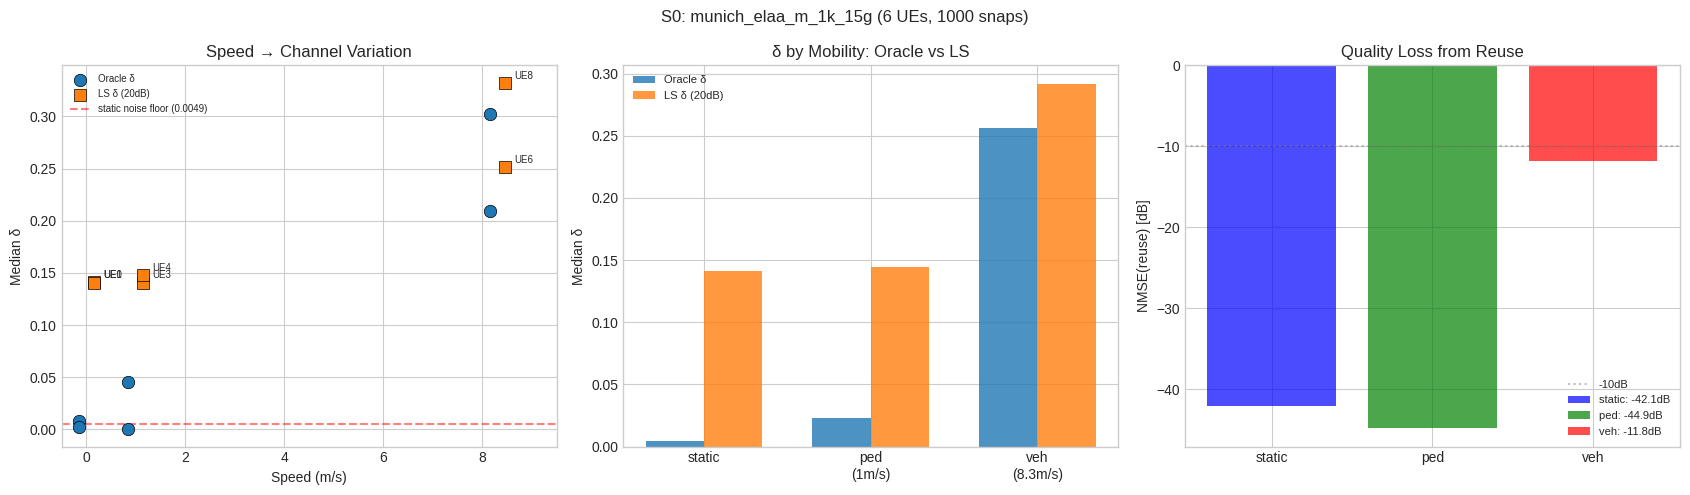

GO/NO-GO: GO ✓ (median δ = 0.0266)


In [ ]:
s0 = run_s0(ue_data)

per_ue = s0["per_ue"]
summary = s0["summary"]
speeds = np.array([u["speed"] for u in per_ue])
deltas_oracle = np.array([u["median_delta"] for u in per_ue])
deltas_ls = np.array([u.get("median_delta_ls", u["median_delta"]) for u in per_ue])
nmses = np.array([u["nmse_reuse_db"] for u in per_ue])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1a: Speed vs δ
ax = axes[0]
for i, u in enumerate(per_ue):
    spd, d_o, d_l = u["speed"], u["median_delta"], u.get("median_delta_ls", u["median_delta"])
    ax.scatter(spd - 0.15, d_o, c="tab:blue", s=80, edgecolors="k", linewidths=0.5, marker="o",
               label="Oracle δ" if i == 0 else "", zorder=5)
    ax.scatter(spd + 0.15, d_l, c="tab:orange", s=80, edgecolors="k", linewidths=0.5, marker="s",
               label="LS δ (20dB)" if i == 0 else "", zorder=5)
    ax.annotate(f"UE{u['uid']}", (spd + 0.2, max(d_o, d_l)), textcoords="offset points", xytext=(5, 3), fontsize=7)
ax.axhline(summary["static_median_delta"], color="red", ls="--", alpha=0.5,
           label=f"static noise floor ({summary['static_median_delta']:.4f})")
ax.set_xlabel("Speed (m/s)"); ax.set_ylabel("Median δ"); ax.set_xlim(-0.5, 9.5)
ax.set_title("Speed → Channel Variation"); ax.legend(fontsize=7, loc="upper left")

# 1b: Grouped bar
ax = axes[1]
cats = {"static": 0.0, "ped\n(1m/s)": 1.0, "veh\n(8.3m/s)": 8.3}
x_pos = np.arange(len(cats)); w = 0.35
for j, (arr, lbl, c) in enumerate([(deltas_oracle, "Oracle δ", "tab:blue"), (deltas_ls, "LS δ (20dB)", "tab:orange")]):
    vals = [np.median(arr[np.abs(speeds - s) < 0.1]) if (np.abs(speeds - s) < 0.1).any() else 0 for _, s in cats.items()]
    ax.bar(x_pos + (j - 0.5) * w, vals, w, color=c, alpha=0.8, label=lbl)
ax.set_xticks(x_pos); ax.set_xticklabels(cats.keys()); ax.set_ylabel("Median δ")
ax.set_title("δ by Mobility: Oracle vs LS"); ax.legend(fontsize=8)

# 1c: NMSE
ax = axes[2]
for i, (lbl, s) in enumerate({"static": 0.0, "ped": 1.0, "veh": 8.3}.items()):
    mask = np.abs(speeds - s) < 0.1; v = nmses[mask]; v = v[~np.isnan(v)]
    if len(v) > 0: ax.bar(i, np.median(v), color=["blue","green","red"][i], alpha=0.7, label=f"{lbl}: {np.median(v):.1f}dB")
ax.axhline(-10, color="gray", ls=":", alpha=0.5, label="-10dB")
ax.set_xticks(range(3)); ax.set_xticklabels(["static","ped","veh"]); ax.set_ylabel("NMSE(reuse) [dB]")
ax.set_title("Quality Loss from Reuse"); ax.legend(fontsize=8)

fig.suptitle(f"S0: {PRESET} ({summary['n_ues']} UEs, {MAX_SNAPSHOTS} snaps)", fontsize=12)
plt.tight_layout(); plt.show()
print(f"GO/NO-GO: {'GO ✓' if summary['median_delta'] <= 0.5 else 'NO-GO ✗'} (median δ = {summary['median_delta']:.4f})")

## Delta Time Series & Deep Dive

**Question:** What does channel variation look like over time? Is delta stationary, or are there spikes/drift patterns that a scheduler must handle?

**Method:** Plot oracle delta(t) for each UE, grouped by mobility class (static / pedestrian / vehicular). The orange dashed line marks the LS noise floor at 20 dB SNR.

**Key insight:** Look for (1) whether static UEs have near-zero delta (confirming skip is trivially safe), (2) whether vehicular UEs show sustained high delta or intermittent spikes, and (3) whether any threshold tau could cleanly separate "safe to skip" from "must re-estimate" slots.

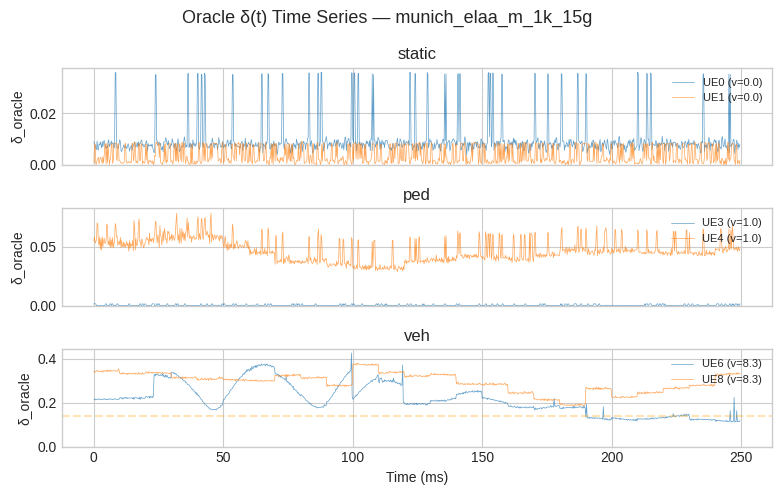

In [ ]:
# δ_oracle time series per UE
import torch

fig, axes = plt.subplots(3, 1, figsize=(8, 5), sharex=True)
speed_groups = {"static": [], "ped": [], "veh": []}
for u in ue_data["ue_list"]:
    lbl = "static" if u["speed"] < 0.1 else ("ped" if u["speed"] < 5 else "veh")
    speed_groups[lbl].append(u)

dt_ms = 0.25  # dt in ms
colors_ue = plt.cm.tab10(np.linspace(0, 1, 10))

for ax, (spd_label, ues) in zip(axes, speed_groups.items()):
    for i, u in enumerate(ues):
        h = u["h_real"]
        # Oracle δ: vectorized
        diff = h[1:] - h[:-1]
        ref = h[:-1].flatten(1).norm(dim=1).clamp(min=1e-12)
        delta_oracle = (diff.flatten(1).norm(dim=1) / ref).numpy()
        t_ms = np.arange(len(delta_oracle)) * dt_ms
        ax.plot(t_ms, delta_oracle, color=colors_ue[i], alpha=0.7, lw=0.5,
                label=f"UE{u['uid']} (v={u['speed']:.1f})")
    
    ax.set_ylabel("δ_oracle")
    ax.set_title(f"{spd_label}")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_ylim(bottom=0)
    # Noise floor reference
    ax.axhline(0.14, color="orange", ls="--", alpha=0.3, label="LS noise floor @20dB")

axes[-1].set_xlabel("Time (ms)")
fig.suptitle(f"Oracle δ(t) Time Series — {ue_data['preset']}", fontsize=13)
plt.tight_layout(); plt.show()

### Deep Dive 1: Spike Analysis — Are large delta jumps common?

**Question:** Are the large delta values caused by rare discrete events (path birth/death) or continuous drift? How frequent are spikes, and what is the "baseline" delta when no spike occurs?

**Method:** Separate delta samples into baseline (delta < 0.3) and spike (delta >= 0.3). Plot baseline distributions and spike statistics per speed group.

**Key insight:** If spikes are rare (< 1-2%), the scheduler can treat them as exceptions (trigger immediate CE). The baseline median tells us the "typical" delta that threshold tuning should target. Compare baseline median to the LS noise floor — if baseline < noise floor, the LS monitor cannot distinguish real change from noise for that speed class.

/tmp/ipykernel_674940/3870155496.py:54: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


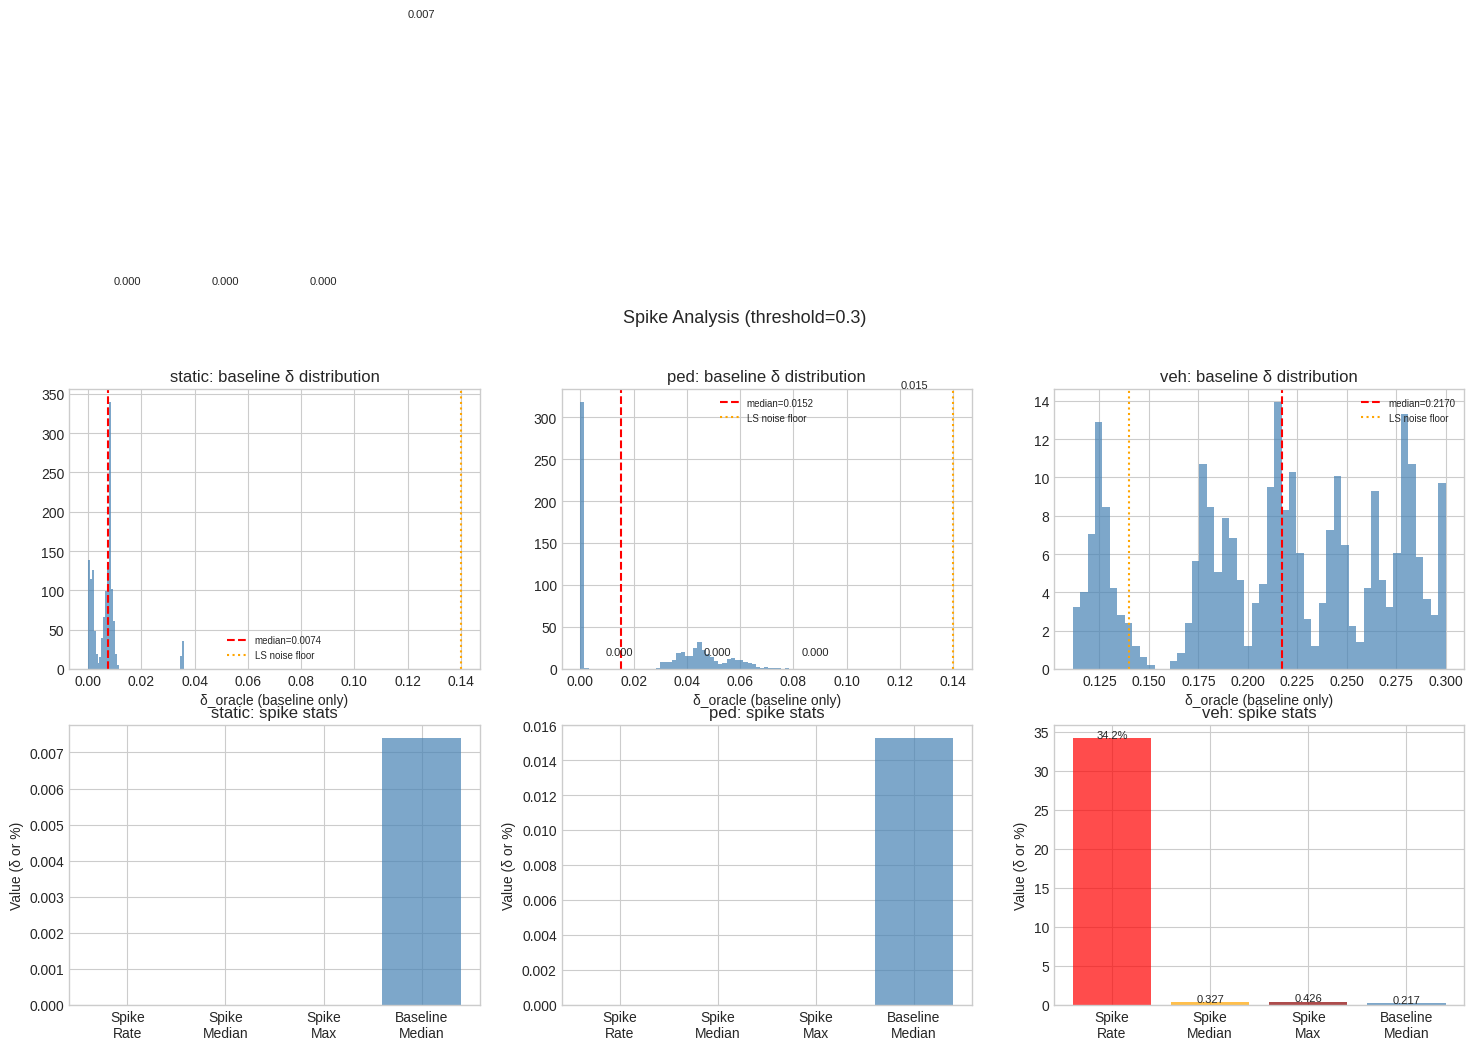

In [ ]:
# ═══ Analysis 1: Spike detection + baseline separation ═══
spike_threshold = 0.3  # δ > 0.3 = spike (path birth/death event)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
dt_ms = 0.25

for col, (spd_label, ues) in enumerate(speed_groups.items()):
    all_baselines, all_spikes = [], []
    
    for u in ues:
        h = u["h_real"]
        diff = h[1:] - h[:-1]
        ref = h[:-1].flatten(1).norm(dim=1).clamp(min=1e-12)
        delta = (diff.flatten(1).norm(dim=1) / ref).numpy()
        
        is_spike = delta > spike_threshold
        baselines = delta[~is_spike]
        spikes = delta[is_spike]
        all_baselines.extend(baselines.tolist())
        all_spikes.extend(spikes.tolist())
    
    all_baselines = np.array(all_baselines)
    all_spikes = np.array(all_spikes)
    T_total = sum(u["h_real"].shape[0] - 1 for u in ues)
    
    # Top: histogram of baseline δ (no spikes)
    ax = axes[0, col]
    if len(all_baselines) > 0:
        ax.hist(all_baselines, bins=50, color="steelblue", alpha=0.7, density=True)
        ax.axvline(np.median(all_baselines), color="red", ls="--", label=f"median={np.median(all_baselines):.4f}")
        ax.axvline(0.14, color="orange", ls=":", label="LS noise floor")
    ax.set_xlabel("δ_oracle (baseline only)")
    ax.set_title(f"{spd_label}: baseline δ distribution")
    ax.legend(fontsize=7)
    
    # Bottom: spike statistics
    ax = axes[1, col]
    spike_rate = len(all_spikes) / max(T_total, 1) * 100
    ax.bar(["Spike\nRate", "Spike\nMedian", "Spike\nMax", "Baseline\nMedian"], 
           [spike_rate, np.median(all_spikes) if len(all_spikes) > 0 else 0,
            np.max(all_spikes) if len(all_spikes) > 0 else 0,
            np.median(all_baselines) if len(all_baselines) > 0 else 0],
           color=["red", "orange", "darkred", "steelblue"], alpha=0.7)
    ax.set_title(f"{spd_label}: spike stats")
    ax.set_ylabel("Value (δ or %)")
    # Annotate
    for i, v in enumerate([spike_rate, 
                           np.median(all_spikes) if len(all_spikes) > 0 else 0,
                           np.max(all_spikes) if len(all_spikes) > 0 else 0,
                           np.median(all_baselines) if len(all_baselines) > 0 else 0]):
        ax.text(i, v + 0.02, f"{v:.3f}" if v < 10 else f"{v:.1f}%", ha="center", fontsize=8)

fig.suptitle(f"Spike Analysis (threshold={spike_threshold})", fontsize=13)
plt.tight_layout(); plt.show()

### Deep Dive 1b: Spike Root Cause — Magnitude or Phase?

**Question:** When a spike occurs, is it caused by a sudden magnitude change (path appearing/disappearing) or a rapid phase rotation?

**Method:** For each spike timestamp, decompose the channel difference into magnitude and phase contributions. Also inspect CIR-level path counts before/after the spike.

**Key insight:** Magnitude-dominated spikes suggest path birth/death events (scatterer transitions), while phase-dominated spikes suggest rapid Doppler shift. This distinction matters for choosing between interpolation-based and re-estimation-based recovery strategies.

In [ ]:
# ═══ Spike Investigation: what happens at spike timestamps? ═══
import h5py
from src.experiments.pipeline import _precompute_deltas

SPIKE_THRESHOLD = 0.3
CONTEXT = 3  # slots before/after spike to show

for u in ue_data["ue_list"][:3]:  # first 3 UEs
    h = u["h_real"]
    T = h.shape[0]
    
    # Oracle δ
    diff = h[1:] - h[:-1]
    ref = h[:-1].flatten(1).norm(dim=1).clamp(min=1e-12)
    delta = (diff.flatten(1).norm(dim=1) / ref).numpy()
    
    spikes = np.where(delta > SPIKE_THRESHOLD)[0] + 1  # +1 because delta[i] = h[i+1]-h[i]
    lbl = "static" if u["speed"] < 0.1 else ("ped" if u["speed"] < 5 else "veh")
    print(f"\n{'═'*60}")
    print(f"UE{u['uid']} ({lbl}, v={u['speed']:.1f}): {len(spikes)} spikes in {T} slots")
    
    if len(spikes) == 0:
        continue
    
    # Show first 3 spikes in detail
    for spike_t in spikes[:3]:
        print(f"\n  ── Spike at t={spike_t} (δ={delta[spike_t-1]:.4f}) ──")
        
        # CFR context
        t_start = max(0, spike_t - CONTEXT)
        t_end = min(T, spike_t + CONTEXT + 1)
        
        for t in range(t_start, t_end):
            h_t = h[t]  # (2, n_ant, n_sc)
            norm = h_t.norm().item()
            # Power per antenna (sum over subcarriers)
            power_per_ant = h_t.pow(2).sum(dim=(0, 2))  # (n_ant,)
            top3_ant = power_per_ant.topk(3)
            
            marker = " <<<" if t == spike_t else ""
            d_str = f"δ={delta[t-1]:.4f}" if t > 0 and t-1 < len(delta) else "       "
            print(f"    t={t:4d}: ||h||={norm:.4e}, {d_str}, "
                  f"top3_ant_power={[f'{v:.2e}' for v in top3_ant.values.tolist()]}{marker}")
        
        # Check: is it a phase flip or magnitude change?
        if spike_t > 0 and spike_t < T:
            h_before = h[spike_t - 1]  # (2, n_ant, n_sc)
            h_after = h[spike_t]
            
            # Magnitude change
            mag_before = h_before.pow(2).sum(0).sqrt()  # (n_ant, n_sc)
            mag_after = h_after.pow(2).sum(0).sqrt()
            mag_ratio = (mag_after / mag_before.clamp(min=1e-12))
            
            # Phase change (complex angle difference)
            h_b_complex = h_before[0] + 1j * h_before[1]  # (n_ant, n_sc)
            h_a_complex = h_after[0] + 1j * h_after[1]
            phase_diff = torch.angle(torch.from_numpy(
                (h_a_complex * h_b_complex.conj()).numpy()
            ))  # (n_ant, n_sc)
            
            print(f"    Magnitude ratio: mean={mag_ratio.mean():.3f}, std={mag_ratio.std():.3f}, "
                  f"min={mag_ratio.min():.3f}, max={mag_ratio.max():.3f}")
            print(f"    Phase diff (rad): mean={phase_diff.mean():.3f}, std={phase_diff.std():.3f}, "
                  f"abs_mean={phase_diff.abs().mean():.3f}")
            
            # Is it magnitude-dominated or phase-dominated?
            # Reconstruct with same magnitude but original phase
            h_mag_only = mag_after / mag_before.clamp(min=1e-12) - 1  # relative mag change
            mag_contribution = h_mag_only.pow(2).mean().sqrt().item()
            phase_contribution = phase_diff.abs().mean().item()
            print(f"    → {'MAGNITUDE' if mag_contribution > phase_contribution else 'PHASE'} dominated "
                  f"(mag={mag_contribution:.4f}, phase={phase_contribution:.4f})")

    # CIR check if h5 available
    h5_path = ue_data["cfg"].temporal_dir / "channels.h5"
    if h5_path.exists() and len(spikes) > 0:
        f = h5py.File(str(h5_path), "r")
        spike_t = spikes[0]
        print(f"\n  ── CIR at spike t={spike_t} ──")
        for t in [spike_t - 1, spike_t]:
            if 0 <= t < f["cir_a"].shape[0]:
                a = f["cir_a"][t, u["uid"]]
                tau = f["cir_tau"][t, u["uid"]]
                valid = np.count_nonzero(np.abs(a).sum(axis=(0, 1)))
                energy = np.abs(a).sum()
                tau_valid = tau[np.abs(a).sum(axis=(0, 1)) > 0]
                print(f"    t={t}: {valid} paths, energy={energy:.4e}, "
                      f"tau range=[{tau_valid.min():.2e}, {tau_valid.max():.2e}]s" if len(tau_valid) > 0 else f"    t={t}: 0 paths")
        f.close()


════════════════════════════════════════════════════════════
UE0 (static, v=0.0): 0 spikes in 1000 slots

════════════════════════════════════════════════════════════
UE1 (static, v=0.0): 0 spikes in 1000 slots

════════════════════════════════════════════════════════════
UE3 (ped, v=1.0): 0 spikes in 1000 slots


### Deep Dive 2: Cumulative Drift — How fast does a stale estimate degrade?

**Question:** If we fix a reference channel at time t0, how quickly does the true channel drift away? This directly determines the maximum skip duration.

**Method:** For multiple reference points t0, compute ||h(t0 + lag) - h(t0)|| / ||h(t0)|| as a function of lag (in ms). Average across reference points for robustness.

**Key insight:** The curve shape reveals the channel aging characteristic. Linear growth = constant Doppler; sublinear = coherent intervals exist. Look for the lag at which drift crosses 10% (mild degradation) and 50% (severe). Static UEs should stay flat; vehicular UEs should cross 50% within a few ms.

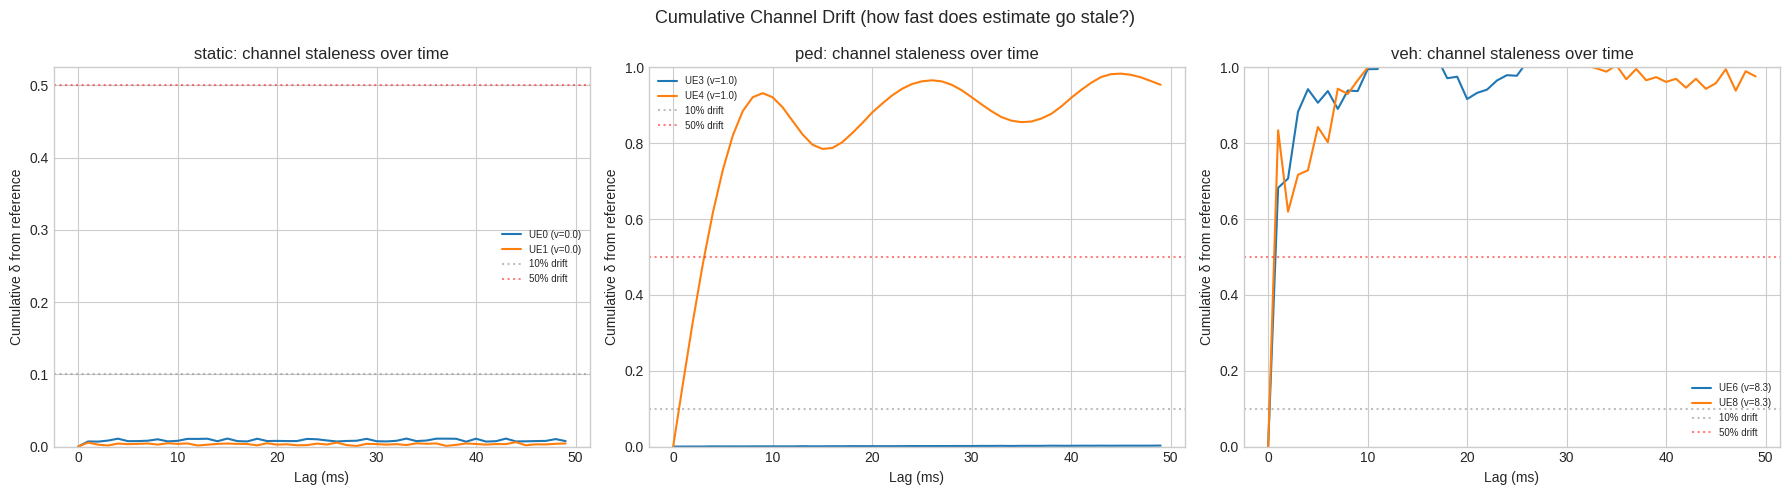

In [ ]:
# ═══ Analysis 2: Cumulative drift — how fast does h_hat go stale? ═══
# ||h(t) - h(t0)||/||h(t0)|| as function of (t - t0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col, (spd_label, ues) in enumerate(speed_groups.items()):
    ax = axes[col]
    
    for u in ues:
        h = u["h_real"]  # (T, 2, n_ant, n_sc)
        T = h.shape[0]
        
        # Sample multiple reference points and average
        ref_points = list(range(0, T - 100, max(T // 10, 1)))[:10]
        drift_curves = []
        
        for t0 in ref_points:
            max_lag = min(200, T - t0)  # up to 200 slots (50ms)
            h_ref = h[t0]  # reference channel
            ref_norm = h_ref.flatten().norm().item()
            if ref_norm < 1e-12:
                continue
            
            lags = list(range(0, max_lag, max(max_lag // 50, 1)))
            drift = []
            for lag in lags:
                d = (h[t0 + lag] - h_ref).flatten().norm().item() / ref_norm
                drift.append(d)
            drift_curves.append((lags, drift))
        
        # Average drift curve
        if drift_curves:
            max_len = min(len(dc[1]) for dc in drift_curves)
            avg_lags = np.array(drift_curves[0][0][:max_len]) * dt_ms
            avg_drift = np.mean([dc[1][:max_len] for dc in drift_curves], axis=0)
            ax.plot(avg_lags, avg_drift, label=f"UE{u['uid']} (v={u['speed']:.1f})", lw=1.5)
    
    ax.set_xlabel("Lag (ms)")
    ax.set_ylabel("Cumulative δ from reference")
    ax.set_title(f"{spd_label}: channel staleness over time")
    ax.axhline(0.1, color="gray", ls=":", alpha=0.5, label="10% drift")
    ax.axhline(0.5, color="red", ls=":", alpha=0.5, label="50% drift")
    ax.legend(fontsize=7)
    ax.set_ylim(0, min(1.0, ax.get_ylim()[1]))

fig.suptitle("Cumulative Channel Drift (how fast does estimate go stale?)", fontsize=13)
plt.tight_layout(); plt.show()

### Deep Dive 3: Oracle delta vs LS delta Overlay

**Question:** How well does the LS-based delta (observable in practice) track the oracle delta (ground truth)? Is the LS noise floor a problem for threshold-based scheduling?

**Method:** Overlay oracle delta and LS delta time series for each UE, with the candidate threshold tau=0.2 and LS noise floor (0.14 at 20 dB) marked as reference lines.

**Key insight:** If LS delta consistently sits above the noise floor for slots where oracle delta is also high, the monitor can reliably detect change. If LS delta is dominated by noise (especially for static/slow UEs), a noise-aware threshold or smoothing is needed. The gap between LS and oracle delta quantifies the "monitoring penalty" of not having perfect CSI.

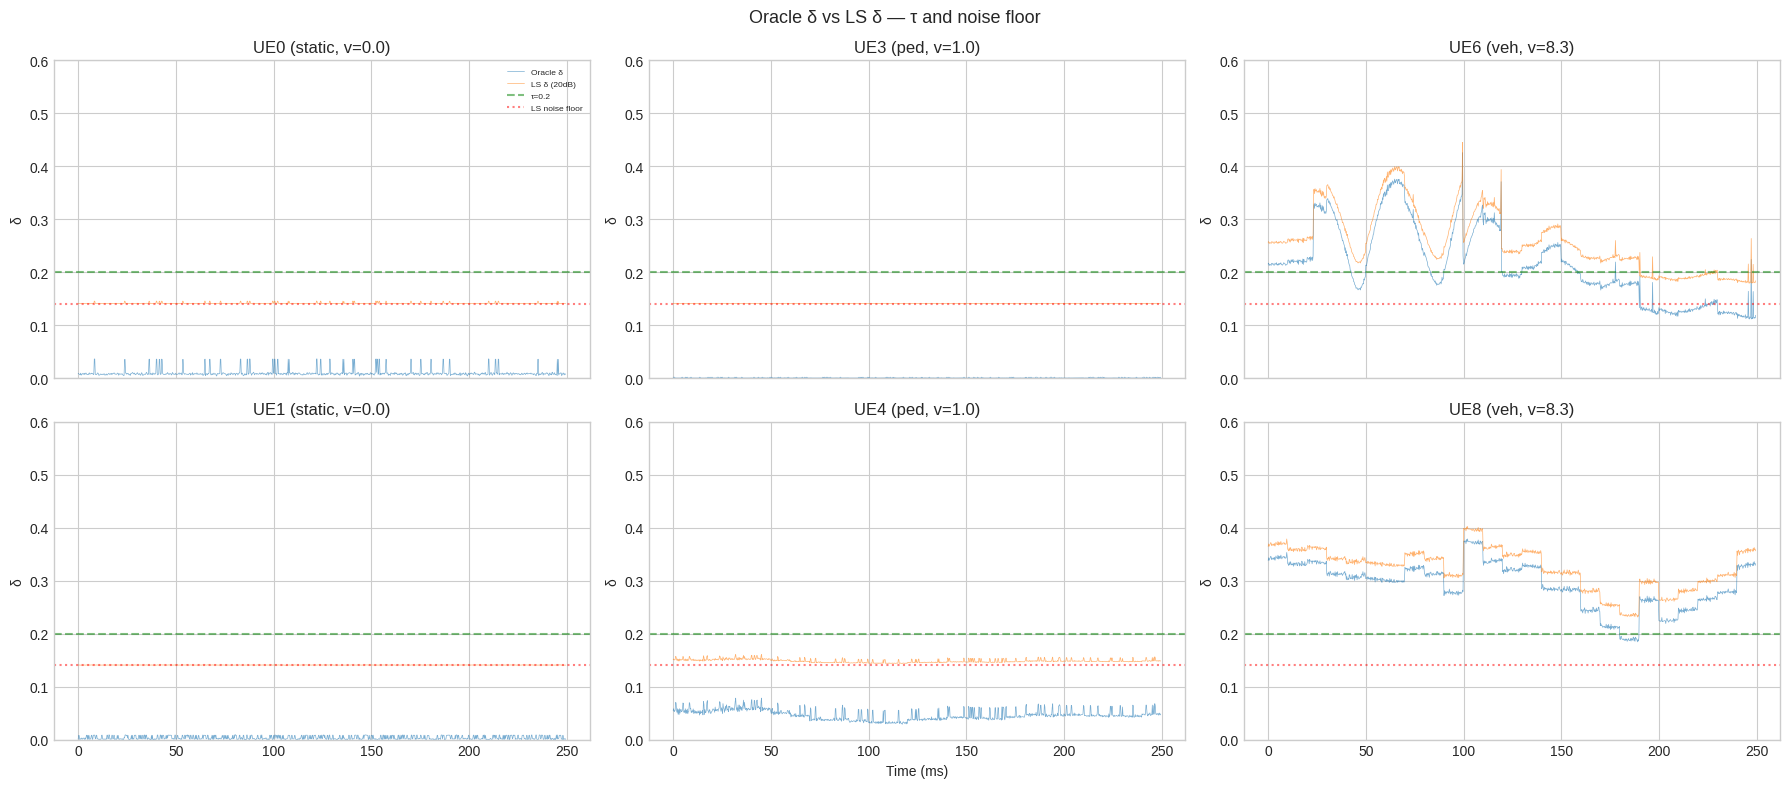

In [ ]:
# ═══ Analysis 3: Oracle δ vs LS δ overlay (per UE) ═══
from src.experiments.pipeline import _precompute_deltas

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)

for col, (spd_label, ues) in enumerate(speed_groups.items()):
    for row, u in enumerate(ues[:2]):  # max 2 UEs per speed
        ax = axes[row, col]
        h = u["h_real"]
        h_ls, d_ls, d_oracle, _ = _precompute_deltas(h, 20.0)
        t_ms = np.arange(len(d_oracle)) * dt_ms
        
        ax.plot(t_ms, d_oracle, color="tab:blue", alpha=0.6, lw=0.5, label="Oracle δ")
        ax.plot(t_ms, d_ls, color="tab:orange", alpha=0.6, lw=0.5, label="LS δ (20dB)")
        ax.axhline(0.2, color="green", ls="--", alpha=0.5, label="τ=0.2")
        ax.axhline(0.14, color="red", ls=":", alpha=0.5, label="LS noise floor")
        ax.set_ylabel("δ")
        ax.set_title(f"UE{u['uid']} ({spd_label}, v={u['speed']:.1f})")
        ax.set_ylim(0, 0.6)  # clip spikes
        if row == 0 and col == 0:
            ax.legend(fontsize=6)

axes[-1, 1].set_xlabel("Time (ms)")
fig.suptitle("Oracle δ vs LS δ — τ and noise floor", fontsize=13)
plt.tight_layout(); plt.show()

### Deep Dive 4: NMSE vs Skip Interval — Maximum Safe Skip Duration

**Question:** If we perform full CE every N slots (fixed interval, no adaptive scheduling), what is the maximum N before NMSE exceeds -10 dB?

**Method:** For each UE, sweep skip intervals from 1 to 500 slots, compute NMSE from channel reuse. Plot NMSE vs interval (log scale). Also compare measured safe intervals to theoretical coherence time T_c = lambda / (2v).

**Key insight:** This gives the **upper bound** on skip rate for periodic scheduling. Adaptive scheduling should do better (skip more during stable periods, less during fast fading). The ratio of measured safe interval to theoretical T_c reveals whether the classical coherence time model is conservative or optimistic for this scenario.

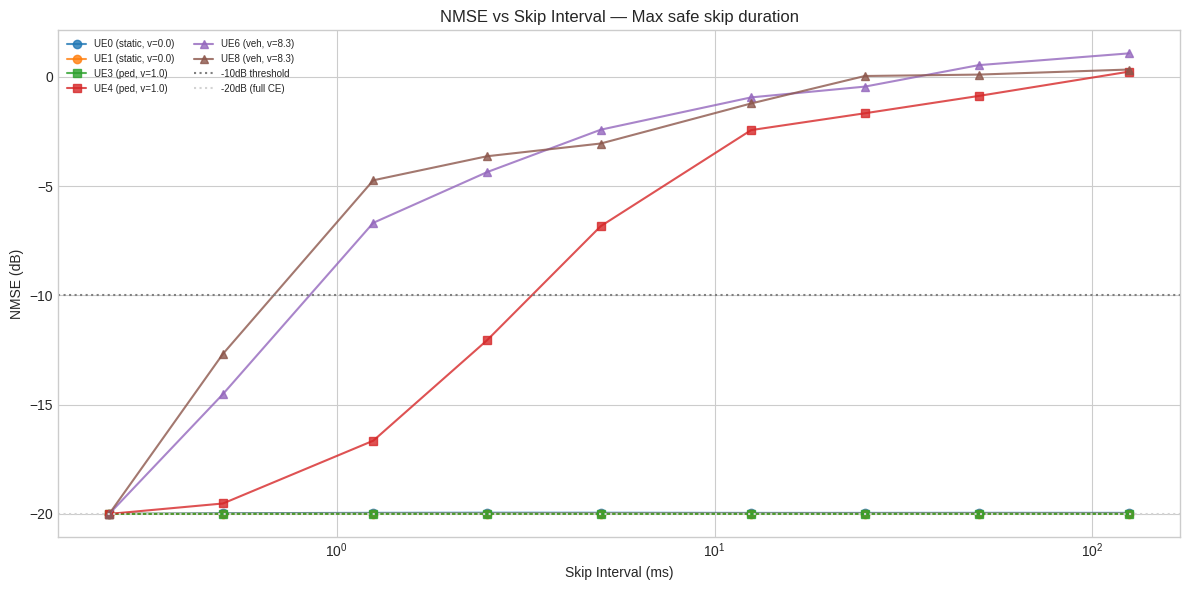


Max safe skip interval (NMSE ≤ -10dB):
  UE0 (static): 500 slots = 125.00ms
  UE1 (static): 500 slots = 125.00ms
  UE3 (ped): 500 slots = 125.00ms
  UE4 (ped): 10 slots = 2.50ms
  UE6 (veh): 2 slots = 0.50ms
  UE8 (veh): 2 slots = 0.50ms


In [ ]:
# ═══ Analysis 4: NMSE vs skip interval (how long can you safely skip?) ═══
# For each UE, artificially skip N slots, measure NMSE. 
# This directly answers: "what's the max skip interval before NMSE > -10dB?"

from src.experiments.pipeline import _precompute_deltas, _compute_nmse_from_tiers

skip_intervals = [1, 2, 5, 10, 20, 50, 100, 200, 500]

fig, ax = plt.subplots(figsize=(12, 6))
markers = {"static": "o", "ped": "s", "veh": "^"}

for spd_label, ues in speed_groups.items():
    for u in ues:
        h = u["h_real"]
        T = h.shape[0]
        h_ls, _, _, _ = _precompute_deltas(h, 20.0)
        
        nmses = []
        for interval in skip_intervals:
            if interval >= T:
                nmses.append(float("nan"))
                continue
            # Build tiers: full CE every `interval` slots
            tiers = np.zeros(T, dtype=np.int32)
            tiers[0] = 2
            for t in range(1, T):
                if t % interval == 0:
                    tiers[t] = 2
            nm = _compute_nmse_from_tiers(h, h_ls, tiers)
            nmses.append(float(10 * np.log10(max(np.mean(nm), 1e-30))))
        
        intervals_ms = [i * dt_ms for i in skip_intervals]
        ax.plot(intervals_ms, nmses, marker=markers[spd_label], 
                label=f"UE{u['uid']} ({spd_label}, v={u['speed']:.1f})", lw=1.5, alpha=0.8)

ax.axhline(-10, color="gray", ls=":", label="-10dB threshold")
ax.axhline(-20, color="lightgray", ls=":", label="-20dB (full CE)")
ax.set_xlabel("Skip Interval (ms)")
ax.set_ylabel("NMSE (dB)")
ax.set_xscale("log")
ax.set_title("NMSE vs Skip Interval — Max safe skip duration")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

# Find max safe interval per UE (NMSE ≤ -10dB)
print("\nMax safe skip interval (NMSE ≤ -10dB):")
for spd_label, ues in speed_groups.items():
    for u in ues:
        h = u["h_real"]
        T = h.shape[0]
        h_ls, _, _, _ = _precompute_deltas(h, 20.0)
        safe = 1
        for interval in skip_intervals:
            if interval >= T:
                break
            tiers = np.zeros(T, dtype=np.int32)
            tiers[0] = 2
            for t in range(1, T):
                if t % interval == 0:
                    tiers[t] = 2
            nm = _compute_nmse_from_tiers(h, h_ls, tiers)
            nmse_db = float(10 * np.log10(max(np.mean(nm), 1e-30)))
            if nmse_db <= -10:
                safe = interval
        print(f"  UE{u['uid']} ({spd_label}): {safe} slots = {safe * dt_ms:.2f}ms")

### Feature Exploration: Which observable signal best predicts the need for CE?

**Question:** Among candidate monitoring features (LS delta, power delta, decorrelation, peak antenna delta, EMA-smoothed delta), which achieves the highest skip rate while keeping NMSE below -10 dB?

**Method:** For each feature, sweep threshold percentiles (5th-99th) and run the scheduling algorithm. Plot the resulting skip-rate vs NMSE Pareto curves per speed class. The feature whose curve extends furthest right (high SR) while staying below -10 dB wins.

**Key insight:** Oracle delta is the theoretical best but unobservable. The practical question is how much skip rate we lose by using an LS-based proxy. EMA smoothing should help by filtering noise. If decorrelation or power delta dominate, simpler monitors may suffice. The best feature may differ by speed class.

Feature sweep:   0%|          | 0/6 [00:00<?, ?ue/s]

  UE0:   0%|          | 0/6 [00:00<?, ?feat/s]

  UE1:   0%|          | 0/6 [00:00<?, ?feat/s]

  UE3:   0%|          | 0/6 [00:00<?, ?feat/s]

  UE4:   0%|          | 0/6 [00:00<?, ?feat/s]

  UE6:   0%|          | 0/6 [00:00<?, ?feat/s]

  UE8:   0%|          | 0/6 [00:00<?, ?feat/s]

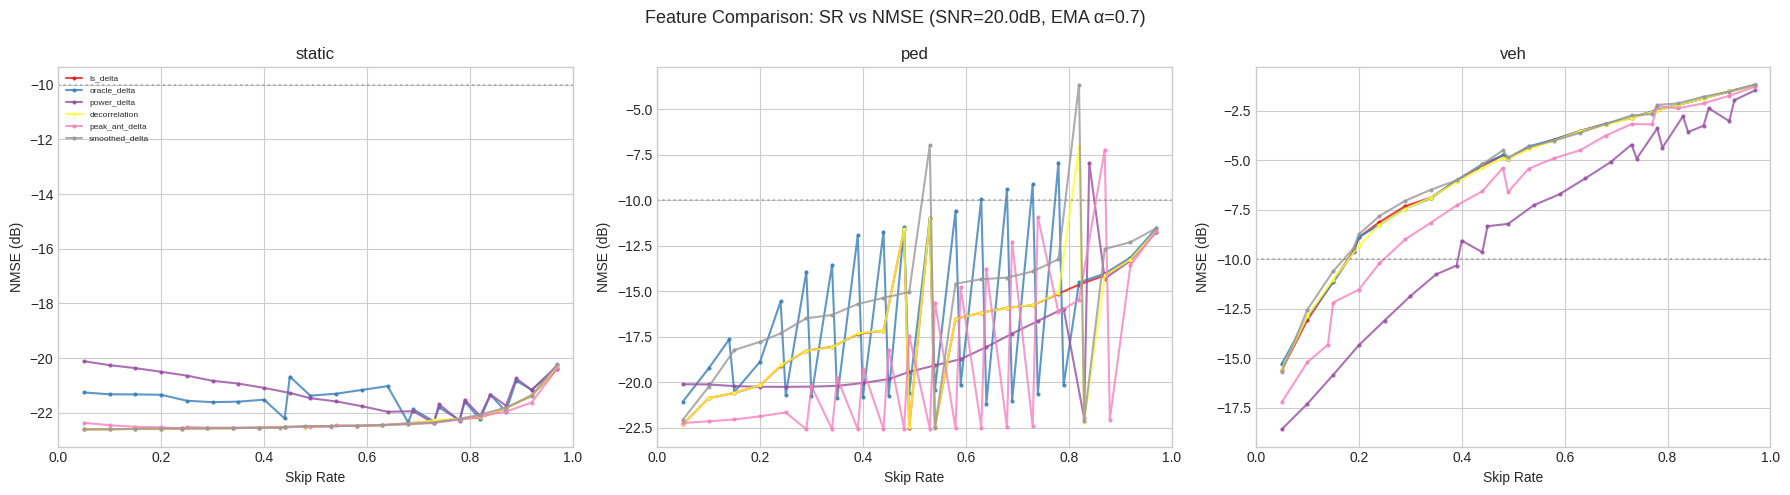


Best feature at NMSE ≤ -10dB:
  static: power_delta → SR=97%
  ped: power_delta → SR=97%
  veh: power_delta → SR=39%


In [ ]:
# ═══ Feature-based scheduling comparison (multi-GPU) ═══
from src.experiments.pipeline import _vectorized_scheduling, _compute_nmse_from_tiers

SNR_DB = 20.0

def compute_features_gpu(h_real, snr_db=20.0):
    """Compute all features — chunked across GPUs to avoid OOM."""
    T = h_real.shape[0]
    n_gpus = torch.cuda.device_count()
    
    # Pick a GPU with most free memory
    free_mem = [torch.cuda.mem_get_info(i)[0] for i in range(n_gpus)]
    best_gpu = max(range(n_gpus), key=lambda i: free_mem[i])
    device = f"cuda:{best_gpu}"
    
    # Estimate memory: h_real (T, 2, n_ant, n_sc) × 4 bytes × ~5 copies
    mem_needed = h_real.nbytes * 5
    chunk_size = T
    if mem_needed > free_mem[best_gpu] * 0.7:
        # Split into chunks that fit
        chunk_size = max(100, int(T * free_mem[best_gpu] * 0.5 / mem_needed))
    
    # Noise on CPU (large), then chunk to GPU for feature computation
    sig_pow = h_real.flatten(1).pow(2).mean(1, keepdim=True).sqrt().unsqueeze(-1).unsqueeze(-1)
    h_ls = h_real + (sig_pow / (10 ** (snr_db / 20))) * torch.randn_like(h_real)
    
    features = {k: [] for k in ["ls_delta", "oracle_delta", "power_delta", 
                                  "decorrelation", "peak_ant_delta", "smoothed_delta"]}
    
    # Process in chunks on GPU
    for start in range(0, T - 1, chunk_size):
        end = min(start + chunk_size + 1, T)  # +1 for diff computation
        h_chunk = h_real[start:end].to(device)
        h_ls_chunk = h_ls[start:end].to(device)
        
        h_flat = h_ls_chunk.flatten(1)
        h_flat_o = h_chunk.flatten(1)
        n = h_flat.shape[0] - 1
        
        if n <= 0:
            break
        
        # LS delta
        diff = h_flat[1:] - h_flat[:-1]
        features["ls_delta"].append((diff.norm(dim=1) / h_flat[:-1].norm(dim=1).clamp(min=1e-12)).cpu())
        
        # Oracle delta
        diff_o = h_flat_o[1:] - h_flat_o[:-1]
        features["oracle_delta"].append((diff_o.norm(dim=1) / h_flat_o[:-1].norm(dim=1).clamp(min=1e-12)).cpu())
        
        # Power delta
        power = h_flat.pow(2).sum(1)
        features["power_delta"].append((torch.abs(power[1:] - power[:-1]) / power[:-1].clamp(min=1e-12)).cpu())
        
        # Decorrelation
        dot = (h_flat[1:] * h_flat[:-1]).sum(1)
        norms = h_flat[1:].norm(dim=1) * h_flat[:-1].norm(dim=1)
        features["decorrelation"].append((1 - dot / norms.clamp(min=1e-12)).cpu())
        
        # Peak antenna delta
        ant_power = h_ls_chunk.pow(2).sum(dim=(1, 3))
        ant_diff = torch.abs(ant_power[1:] - ant_power[:-1])
        features["peak_ant_delta"].append((ant_diff / ant_power[:-1].clamp(min=1e-12)).max(dim=1).values.cpu())
        
        del h_chunk, h_ls_chunk, h_flat, h_flat_o, diff, diff_o
        torch.cuda.empty_cache()
    
    # Smoothed delta (sequential, CPU — small per-element ops)
    alpha_s = 0.4
    h_smooth = torch.zeros_like(h_ls)
    h_smooth[0] = h_ls[0]
    for t in range(1, T):
        h_smooth[t] = alpha_s * h_ls[t] + (1 - alpha_s) * h_smooth[t - 1]
    diff_s = h_smooth[1:].flatten(1) - h_smooth[:-1].flatten(1)
    features["smoothed_delta"].append(
        (diff_s.norm(dim=1) / h_smooth[:-1].flatten(1).norm(dim=1).clamp(min=1e-12)))
    del h_smooth
    
    # Concat chunks
    result = {k: torch.cat(v).numpy() if isinstance(v[0], torch.Tensor) else np.concatenate(v)
              for k, v in features.items()}
    
    return h_ls, result


# Sweep
all_results = {}
percentiles = np.linspace(5, 99, 20)

from tqdm.auto import tqdm
for u in tqdm(ue_data["ue_list"], desc="Feature sweep", unit="ue"):
    h = u["h_real"]
    h_ls, features = compute_features_gpu(h, SNR_DB)
    lbl = "static" if u["speed"] < 0.1 else ("ped" if u["speed"] < 5 else "veh")
    
    for feat_name, feat_vals in tqdm(features.items(), desc=f"  UE{u['uid']}", leave=False, unit="feat"):
        if feat_name not in all_results:
            all_results[feat_name] = {"static": [], "ped": [], "veh": []}
        
        thresholds = np.percentile(feat_vals, percentiles)
        for tau in thresholds:
            sched = _vectorized_scheduling(feat_vals, tau_low=tau, tau_high=2 * tau)
            nm = _compute_nmse_from_tiers(h, h_ls, sched["tiers"], alpha=0.7, delta_mode="ema")
            sr = sched["n_skip"] / sched["total"]
            all_results[feat_name][lbl].append({
                "sr": sr, "nmse": float(10 * np.log10(max(np.mean(nm), 1e-30))), "uid": u["uid"]
            })

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
feat_colors = plt.cm.Set1(np.linspace(0, 1, len(all_results)))

for col, spd_label in enumerate(["static", "ped", "veh"]):
    ax = axes[col]
    for fi, (feat_name, speed_data) in enumerate(all_results.items()):
        pts = speed_data[spd_label]
        if not pts:
            continue
        sr_bins = {}
        for p in pts:
            sr_bins.setdefault(round(p["sr"], 2), []).append(p["nmse"])
        srs = sorted(sr_bins.keys())
        ax.plot(srs, [np.mean(sr_bins[s]) for s in srs], marker=".", ms=4,
                label=feat_name, color=feat_colors[fi], alpha=0.8)
    
    ax.axhline(-10, color="gray", ls=":", alpha=0.5)
    ax.set_xlabel("Skip Rate"); ax.set_ylabel("NMSE (dB)"); ax.set_title(spd_label)
    if col == 0: ax.legend(fontsize=6, loc="upper left")
    ax.set_xlim(0, 1)

fig.suptitle(f"Feature Comparison: SR vs NMSE (SNR={SNR_DB}dB, EMA α=0.7)", fontsize=13)
plt.tight_layout(); plt.show()

print("\nBest feature at NMSE ≤ -10dB:")
for spd_label in ["static", "ped", "veh"]:
    best_feat, best_sr = None, -1
    for feat_name, speed_data in all_results.items():
        for p in speed_data[spd_label]:
            if p["nmse"] <= -10 and p["sr"] > best_sr:
                best_sr = p["sr"]
                best_feat = feat_name
    print(f"  {spd_label}: {best_feat} → SR={best_sr:.0%}" if best_feat else f"  {spd_label}: none")

### Deep Dive 6: Does noise-floor-level skip actually hurt NMSE?

**Question:** The LS noise floor is ~0.14 at 20 dB. If we set tau near the noise floor, we skip whenever delta_LS < tau -- ignoring both noise AND real channel changes up to that level. Is that safe?

**Method:** Sweep tau from 0 to 0.3 using both oracle delta (blue, ideal) and LS delta (red, practical) for scheduling. Compare NMSE at tau = noise_floor.

**Key insight:** If NMSE stays acceptable (< -10 dB) at tau = noise_floor, then the noise floor is not a liability but a *natural skip threshold* -- changes below it are too small to matter. If NMSE degrades, we need a sub-noise-floor monitor (e.g., accumulating delta over multiple slots).

In [ ]:
# ═══ Noise floor skip test: does skipping at δ < noise_floor hurt? ═══
from src.experiments.pipeline import _precompute_deltas, _vectorized_scheduling, _compute_nmse_from_tiers

SNR_TEST = 20.0
noise_floor = np.sqrt(2.0 / (10 ** (SNR_TEST / 10)))  # ≈ 0.141
print(f"LS noise floor @{SNR_TEST}dB: {noise_floor:.4f}")

# For each UE: 
# 1. Use ORACLE δ to schedule (skip if oracle δ < threshold)
# 2. Sweep threshold from 0 to 0.3 (beyond noise floor)
# 3. Measure NMSE — if NMSE stays good even at τ=noise_floor, then noise floor is harmless
thresholds = np.linspace(0.001, 0.3, 30)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
speed_groups_local = {"static": [], "ped": [], "veh": []}
for u in ue_data["ue_list"]:
    lbl = "static" if u["speed"] < 0.1 else ("ped" if u["speed"] < 5 else "veh")
    speed_groups_local[lbl].append(u)

for col, (spd_label, ues) in enumerate(speed_groups_local.items()):
    ax = axes[col]
    
    for u in ues:
        h = u["h_real"]
        h_ls, d_ls, d_oracle, _ = _precompute_deltas(h, SNR_TEST)
        
        nmses_oracle_sched = []  # NMSE when scheduling with ORACLE δ
        nmses_ls_sched = []      # NMSE when scheduling with LS δ
        srs_oracle = []
        srs_ls = []
        
        for tau in thresholds:
            # Oracle-based scheduling
            sched_o = _vectorized_scheduling(d_oracle, tau_low=tau, tau_high=2*tau)
            nm_o = _compute_nmse_from_tiers(h, h_ls, sched_o["tiers"], alpha=0.7, delta_mode="ema")
            nmses_oracle_sched.append(10 * np.log10(max(np.mean(nm_o), 1e-30)))
            srs_oracle.append(sched_o["n_skip"] / sched_o["total"])
            
            # LS-based scheduling
            sched_l = _vectorized_scheduling(d_ls, tau_low=tau, tau_high=2*tau)
            nm_l = _compute_nmse_from_tiers(h, h_ls, sched_l["tiers"], alpha=0.7, delta_mode="ema")
            nmses_ls_sched.append(10 * np.log10(max(np.mean(nm_l), 1e-30)))
            srs_ls.append(sched_l["n_skip"] / sched_l["total"])
        
        ax.plot(thresholds, nmses_oracle_sched, "b-", lw=1.5, alpha=0.7,
                label=f"UE{u['uid']} oracle" if u == ues[0] else "")
        ax.plot(thresholds, nmses_ls_sched, "r--", lw=1, alpha=0.5,
                label=f"UE{u['uid']} LS" if u == ues[0] else "")
    
    ax.axvline(noise_floor, color="orange", ls=":", lw=2, label=f"noise floor={noise_floor:.3f}")
    ax.axhline(-10, color="gray", ls=":", alpha=0.5)
    ax.axhline(-20, color="lightgray", ls=":", alpha=0.3, label="full CE level")
    ax.set_xlabel("Threshold τ")
    ax.set_ylabel("NMSE (dB)")
    ax.set_title(f"{spd_label}")
    ax.legend(fontsize=7)

fig.suptitle(f"NMSE vs Threshold: Oracle scheduling (blue) vs LS scheduling (red)\n"
             f"If NMSE stays low at τ=noise_floor → safe to skip at noise floor level", fontsize=11)
plt.tight_layout(); plt.show()

# Print key numbers at noise floor threshold
print(f"\n{'='*60}")
print(f"At τ = noise_floor ({noise_floor:.3f}):")
print(f"{'='*60}")
for u in ue_data["ue_list"]:
    h = u["h_real"]
    h_ls, d_ls, d_oracle, _ = _precompute_deltas(h, SNR_TEST)
    lbl = "static" if u["speed"] < 0.1 else ("ped" if u["speed"] < 5 else "veh")
    
    sched_o = _vectorized_scheduling(d_oracle, tau_low=noise_floor, tau_high=2*noise_floor)
    nm_o = _compute_nmse_from_tiers(h, h_ls, sched_o["tiers"], alpha=0.7, delta_mode="ema")
    nmse_o = 10 * np.log10(max(np.mean(nm_o), 1e-30))
    sr_o = sched_o["n_skip"] / sched_o["total"]
    
    sched_l = _vectorized_scheduling(d_ls, tau_low=noise_floor, tau_high=2*noise_floor)
    nm_l = _compute_nmse_from_tiers(h, h_ls, sched_l["tiers"], alpha=0.7, delta_mode="ema")
    nmse_l = 10 * np.log10(max(np.mean(nm_l), 1e-30))
    sr_l = sched_l["n_skip"] / sched_l["total"]
    
    print(f"  UE{u['uid']} ({lbl}): oracle→NMSE={nmse_o:.1f}dB SR={sr_o:.0%} | LS→NMSE={nmse_l:.1f}dB SR={sr_l:.0%}")

### UE3 vs UE4: Why does UE4 fail while UE3 succeeds?

Both are ped (1 m/s), similar displacement. But UE3 δ≈0, UE4 δ≈0.05.
Root cause analysis: path count, path diversity, geometry, LOS/NLOS.

### CE Method Comparison: LS vs LMMSE vs DL-CE (PACENet)
Compare NMSE of different CE methods on the temporal test data (BS 1 UEs).
This validates that DL-CE improves over LS, and quantifies the skip benefit per CE method.

In [ ]:
# ═══ CE Method Comparison: LS vs Genie-LMMSE vs DL-CE (PACENet) ═══
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "2")

from src.models.estimator import create_model as create_pacenet
from src.ce_skip.ce_algorithms import GenieLMMSE
from src.training.trainer import load_checkpoint
from src.dataset_operation.utils import nmse as compute_nmse
from tqdm.auto import tqdm

PRESET = ue_data["preset"]
device = "cuda" if torch.cuda.is_available() else "cpu"
SNR_EVAL = [10, 15, 20, 25, 30]

# Load DL-CE checkpoint
short = PRESET.replace("munich_", "")
ckpt_name = f"ce_skip/dl_ce_{short}"
dl_model = create_pacenet(site_integration="none").to(device)
try:
    meta = load_checkpoint(dl_model, ckpt_name, device=device)
    dl_model.eval()
    dl_available = True
    print(f"DL-CE loaded: {ckpt_name}, val={meta.get('best_val_db', '?')}dB")
except Exception as e:
    dl_available = False
    print(f"DL-CE not available: {e}")

# Fit Genie-LMMSE on training data (BS 0,2,3 from independent drops)
from src.dataset_operation.dataset import ChannelEstimationDataset
from torch.utils.data import DataLoader

lmmse = GenieLMMSE(device=device)
try:
    fit_ds = ChannelEstimationDataset(
        f"assets/data/channels_{short}", bs_ids=[0,2,3],
        snapshot_ids=list(range(5)), snr_range_db=(20,20))
    fit_loader = DataLoader(fit_ds, batch_size=min(64, len(fit_ds)), shuffle=False)
    h_fit = []
    for batch in fit_loader:
        h_fit.append(batch["target"])
        if sum(s.shape[0] for s in h_fit) >= 500:
            break
    h_fit = torch.cat(h_fit)[:500].to(device)
    # Filter zero samples
    valid = h_fit.flatten(1).pow(2).sum(1) > 1e-20
    h_fit = h_fit[valid]
    lmmse.fit(h_fit)
    lmmse_available = True
    print(f"LMMSE fitted on {len(h_fit)} samples")
except Exception as e:
    lmmse_available = False
    print(f"LMMSE not available: {e}")

# Evaluate on temporal test UEs
results = {snr: {"LS": [], "LMMSE": [], "DL-CE": []} for snr in SNR_EVAL}

for u in tqdm(ue_data["ue_list"], desc="CE comparison", unit="ue"):
    h = u["h_real"]  # (T, 2, n_ant, n_sc) on CPU
    T = h.shape[0]
    
    for snr_db in SNR_EVAL:
        # Generate noisy LS
        sig_pow = h.flatten(1).pow(2).mean(1, keepdim=True).sqrt().unsqueeze(-1).unsqueeze(-1)
        h_ls = h + (sig_pow / (10 ** (snr_db / 20))) * torch.randn_like(h)
        
        # LS NMSE (baseline)
        nmse_ls = compute_nmse(h_ls, h).item()
        results[snr_db]["LS"].append(10 * np.log10(max(nmse_ls, 1e-30)))
        
        # LMMSE
        if lmmse_available:
            with torch.no_grad():
                # Process in chunks to avoid OOM
                chunk = 50
                nmse_vals = []
                for i in range(0, T, chunk):
                    j = min(i + chunk, T)
                    h_lmmse = lmmse(h_ls[i:j].to(device), snr_db=snr_db).cpu()
                    nmse_vals.append(compute_nmse(h_lmmse, h[i:j]).item())
                results[snr_db]["LMMSE"].append(10 * np.log10(max(np.mean(nmse_vals), 1e-30)))
        
        # DL-CE
        if dl_available:
            with torch.no_grad():
                chunk = 20
                nmse_vals = []
                for i in range(0, T, chunk):
                    j = min(i + chunk, T)
                    h_in = h_ls[i:j].to(device)
                    rms = h_in.flatten(1).pow(2).mean(1).sqrt().clamp(min=1e-10).view(-1,1,1,1)
                    h_hat = dl_model(h_in / rms) * rms
                    nmse_vals.append(compute_nmse(h_hat.cpu(), h[i:j]).item())
                results[snr_db]["DL-CE"].append(10 * np.log10(max(np.mean(nmse_vals), 1e-30)))

# Plot: NMSE vs SNR for each CE method
fig, ax = plt.subplots(figsize=(10, 6))
method_styles = {"LS": ("tab:red", "o", "--"), "LMMSE": ("tab:blue", "s", "-"), "DL-CE": ("tab:green", "^", "-")}

for method, (color, marker, ls) in method_styles.items():
    if not any(results[snr][method] for snr in SNR_EVAL):
        continue
    means = [np.mean(results[snr][method]) if results[snr][method] else float("nan") for snr in SNR_EVAL]
    ax.plot(SNR_EVAL, means, color=color, marker=marker, ls=ls, lw=2, ms=8, label=method)

ax.set_xlabel("SNR (dB)"); ax.set_ylabel("NMSE (dB)")
ax.set_title(f"CE Method Comparison — {PRESET}")
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Table
print(f"\n{'SNR':>5s} | {'LS':>8s} | {'LMMSE':>8s} | {'DL-CE':>8s} | {'DL-CE gain':>10s}")
print("-" * 50)
for snr in SNR_EVAL:
    ls = np.mean(results[snr]["LS"]) if results[snr]["LS"] else float("nan")
    lm = np.mean(results[snr]["LMMSE"]) if results[snr]["LMMSE"] else float("nan")
    dl = np.mean(results[snr]["DL-CE"]) if results[snr]["DL-CE"] else float("nan")
    gain = ls - dl if not (np.isnan(ls) or np.isnan(dl)) else float("nan")
    print(f"{snr:5d} | {ls:8.1f} | {lm:8.1f} | {dl:8.1f} | {gain:+8.1f} dB")

In [ ]:
# ═══ UE3 vs UE4 deep comparison ═══
import h5py
from src.experiments.pipeline import _precompute_deltas

ue3 = [u for u in ue_data["ue_list"] if u["uid"] == 3][0]
ue4 = [u for u in ue_data["ue_list"] if u["uid"] == 4][0]

h5_path = str(ue_data["cfg"].temporal_dir / "channels.h5")
f = h5py.File(h5_path, "r")

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle("UE3 vs UE4: Why does UE4 fail CE skip?", fontsize=14)

for col, (u, uid) in enumerate([(ue3, 3), (ue4, 4)]):
    h = u["h_real"]
    T = h.shape[0]
    
    # Row 0: CIR properties — path count + energy over time
    ax = axes[0, col]
    path_counts = []
    energies = []
    for t in range(T):
        a = f["cir_a"][t, uid]
        n = np.count_nonzero(np.abs(a).sum(axis=(0, 1)))
        e = float(np.abs(a).sum())
        path_counts.append(n)
        energies.append(e)
    t_ms = np.arange(T) * 0.25
    ax2 = ax.twinx()
    ax.plot(t_ms, path_counts, "b-", lw=0.8, label="paths")
    ax2.plot(t_ms, energies, "r-", lw=0.8, alpha=0.5, label="energy")
    ax.set_ylabel("Path count", color="b")
    ax2.set_ylabel("CIR energy", color="r")
    ax.set_title(f"UE{uid} (ped): CIR properties")
    ax.legend(loc="upper left", fontsize=7)
    ax2.legend(loc="upper right", fontsize=7)
    
    # Row 1: CFR power spectrum at t=0 (which antennas/subcarriers have energy?)
    ax = axes[1, col]
    h0 = h[0]  # (2, n_ant, n_sc)
    power_spec = h0.pow(2).sum(0)  # (n_ant, n_sc) — sum real/imag
    # Average over antennas → per-subcarrier power
    avg_sc_power = power_spec.mean(0).numpy()  # (n_sc,)
    # Average over subcarriers → per-antenna power
    avg_ant_power = power_spec.mean(1).numpy()  # (n_ant,)
    
    ax.semilogy(avg_sc_power, lw=0.5, alpha=0.7, label="per-SC (avg over ant)")
    ax.set_xlabel("Subcarrier")
    ax.set_ylabel("Power (log)")
    ax.set_title(f"UE{uid}: CFR power spectrum (t=0)")
    ax.legend(fontsize=7)
    
    # Row 2: δ time series (oracle) + autocorrelation
    ax = axes[2, col]
    _, _, d_oracle, _ = _precompute_deltas(h, 20.0)
    ax.plot(t_ms[1:], d_oracle, lw=0.5, alpha=0.7, color="tab:blue")
    ax.axhline(np.median(d_oracle), color="red", ls="--", alpha=0.5, label=f"median={np.median(d_oracle):.4f}")
    ax.axhline(0.14, color="orange", ls=":", alpha=0.5, label="LS noise floor")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Oracle δ")
    ax.set_title(f"UE{uid}: δ oracle time series")
    ax.legend(fontsize=7)
    ax.set_ylim(0, max(0.1, np.percentile(d_oracle, 99) * 1.2))

plt.tight_layout()
plt.show()

# Print summary comparison
print(f"\n{'='*60}")
print(f"{'':20s} {'UE3':>15s} {'UE4':>15s}")
print(f"{'='*60}")
for label, vals in [
    ("Speed (m/s)", (ue3["speed"], ue4["speed"])),
    ("Distance (m)", (ue3["dist"], ue4["dist"])),
    ("Path count (t=0)", (path_counts[0] if col==1 else "?", path_counts[0])),
]:
    print(f"{label:20s} {str(vals[0]):>15s} {str(vals[1]):>15s}")

# Recompute for both
for uid_check, u_check in [(3, ue3), (4, ue4)]:
    h_c = u_check["h_real"]
    _, _, d_o, _ = _precompute_deltas(h_c, 20.0)
    
    a0 = f["cir_a"][0, uid_check]
    n_paths = np.count_nonzero(np.abs(a0).sum(axis=(0, 1)))
    energy = np.abs(a0).sum()
    
    # Delay spread
    tau0 = f["cir_tau"][0, uid_check]
    a0_power = np.abs(a0).sum(axis=(0, 1))  # per-path power
    valid = a0_power > 1e-12
    if valid.any():
        tau_valid = tau0[valid]
        delay_spread = float(np.std(tau_valid))
        tau_range = float(tau_valid.max() - tau_valid.min())
    else:
        delay_spread = 0
        tau_range = 0
    
    # Dominant path ratio (strongest path / total energy)
    a0_sorted = np.sort(a0_power[valid])[::-1]
    dominant_ratio = a0_sorted[0] / a0_sorted.sum() if len(a0_sorted) > 0 else 0
    
    print(f"\nUE{uid_check}:")
    print(f"  Paths: {n_paths}, Energy: {energy:.4e}")
    print(f"  Delay spread: {delay_spread:.2e}s, Range: {tau_range:.2e}s")
    print(f"  Dominant path ratio: {dominant_ratio:.1%} (1 path / total)")
    print(f"  Oracle δ: median={np.median(d_o):.6f}, mean={np.mean(d_o):.6f}")
    print(f"  → {'LOS-dominant (skip safe)' if dominant_ratio > 0.5 else 'Multipath-rich (skip risky)'}")

f.close()

### Deep Dive 5: Coherence Time — Theory vs Measurement

**Question:** Does the classical coherence time formula T_c = lambda/(2v) accurately predict how long a channel estimate remains usable?

**Method:** Compare theoretical T_c (from carrier frequency and UE speed) with the empirically measured maximum safe skip interval (NMSE <= -10 dB). The ratio reveals whether theory over- or under-estimates coherence.

**Key insight:** Ratio < 1 means theory is optimistic (real channel changes faster than predicted, likely due to multipath). Ratio > 1 means theory is conservative (channel is more stable, likely LOS-dominated). Large variance across UEs at the same speed indicates environment-dependent coherence, motivating adaptive rather than fixed scheduling.

In [ ]:
# ═══ Analysis 5: Coherence time comparison (theoretical vs measured) ═══
c = 3e8
frequency = 15e9  # for elaa_m_1k_15g
wavelength = c / frequency

print(f"Config: f={frequency/1e9:.0f}GHz, λ={wavelength*100:.1f}cm, dt={dt_ms}ms\n")
print(f"{'UE':>5} {'Speed':>8} {'T_c (theory)':>14} {'T_c (slots)':>12} {'Safe skip':>12} {'Ratio':>8}")
print("-" * 65)

for spd_label, ues in speed_groups.items():
    for u in ues:
        v = u["speed"]
        if v < 0.01:
            tc_theory = float("inf")
            tc_slots = float("inf")
        else:
            tc_theory = wavelength / (2 * v)  # seconds
            tc_slots = tc_theory / (dt_ms / 1000)
        
        # Measured safe skip from Analysis 4 (find from data)
        h = u["h_real"]
        T = h.shape[0]
        h_ls, _, _, _ = _precompute_deltas(h, 20.0)
        safe_measured = 1
        for interval in [1, 2, 5, 10, 20, 50, 100, 200, 500]:
            if interval >= T:
                break
            tiers = np.zeros(T, dtype=np.int32)
            tiers[0] = 2
            for t in range(1, T):
                if t % interval == 0:
                    tiers[t] = 2
            nm = _compute_nmse_from_tiers(h, h_ls, tiers)
            if 10 * np.log10(max(np.mean(nm), 1e-30)) <= -10:
                safe_measured = interval
        
        tc_str = f"{tc_theory*1000:.2f}ms" if tc_theory < 1 else "∞"
        slots_str = f"{tc_slots:.0f}" if tc_slots < 10000 else "∞"
        ratio = safe_measured / tc_slots if tc_slots < 10000 and tc_slots > 0 else float("nan")
        
        print(f"UE{u['uid']:>2d}  {v:>6.1f}m/s  {tc_str:>14}  {slots_str:>12}  {safe_measured:>8d} slots  {ratio:>6.2f}x")

print(f"\nRatio = measured_safe / theoretical_T_c")
print(f"  <1: theory is optimistic (skip less than predicted)")
print(f"  >1: theory is conservative (can skip more than predicted)")
print(f"  ≈1: theory matches measurement")

Config: f=15GHz, λ=2.0cm, dt=0.25ms

   UE    Speed   T_c (theory)  T_c (slots)    Safe skip    Ratio
-----------------------------------------------------------------
UE 0     0.0m/s               ∞             ∞       500 slots     nanx
UE 1     0.0m/s               ∞             ∞       500 slots     nanx
UE 3     1.0m/s         10.00ms            40       500 slots   12.50x
UE 4     1.0m/s         10.00ms            40        10 slots    0.25x
UE 6     8.3m/s          1.20ms             5         2 slots    0.42x
UE 8     8.3m/s          1.20ms             5         2 slots    0.42x

Ratio = measured_safe / theoretical_T_c
  <1: theory is optimistic (skip less than predicted)
  >1: theory is conservative (can skip more than predicted)
  ≈1: theory matches measurement


## S1: Monitor Comparison — Which scheduling strategy works best?

**Question:** At a fixed threshold tau=0.2, how do different adaptive scheduling strategies compare to the baselines of always-full-CE and always-skip?

**Method:** Run each strategy (oracle, LS-based, SNR-adaptive, EMA, etc.) on all UEs. Compare NMSE (quality) and skip rate (efficiency) per mobility class.

**Key insight:** A good strategy should match always-full-CE quality (NMSE near full-CE baseline) while achieving substantial skip rate. Look for strategies that degrade gracefully with speed — high SR for static, moderate for pedestrian, low but nonzero for vehicular. If a strategy has high SR but poor NMSE, it is over-skipping.

S1: monitor comparison (τ=0.2):   0%|          | 0/6 [00:00<?, ?ue/s]

  UE0 (v=0.0):
    full_ce             : NMSE= -20.0dB  SR=0%
    always_skip         : NMSE= -20.0dB  SR=100%
    ls_monitor          : NMSE= -20.0dB  SR=98%
    oracle_monitor      : NMSE= -20.0dB  SR=98%
    doppler             : NMSE= -20.0dB  SR=98%
    snr_adaptive        : NMSE= -20.0dB  SR=98%
    smoothed_ls_K4      : NMSE= -20.0dB  SR=98%
  UE1 (v=0.0):
    full_ce             : NMSE= -20.0dB  SR=0%
    always_skip         : NMSE= -20.0dB  SR=100%
    ls_monitor          : NMSE= -20.0dB  SR=98%
    oracle_monitor      : NMSE= -20.0dB  SR=98%
    doppler             : NMSE= -20.0dB  SR=98%
    snr_adaptive        : NMSE= -20.0dB  SR=98%
    smoothed_ls_K4      : NMSE= -20.0dB  SR=98%
  UE3 (v=1.0):
    full_ce             : NMSE= -20.0dB  SR=0%
    always_skip         : NMSE= -20.0dB  SR=100%
    ls_monitor          : NMSE= -20.0dB  SR=98%
    oracle_monitor      : NMSE= -20.0dB  SR=98%
    doppler             : NMSE= -20.0dB  SR=98%
    snr_adaptive        : NMSE= -20.0dB  SR

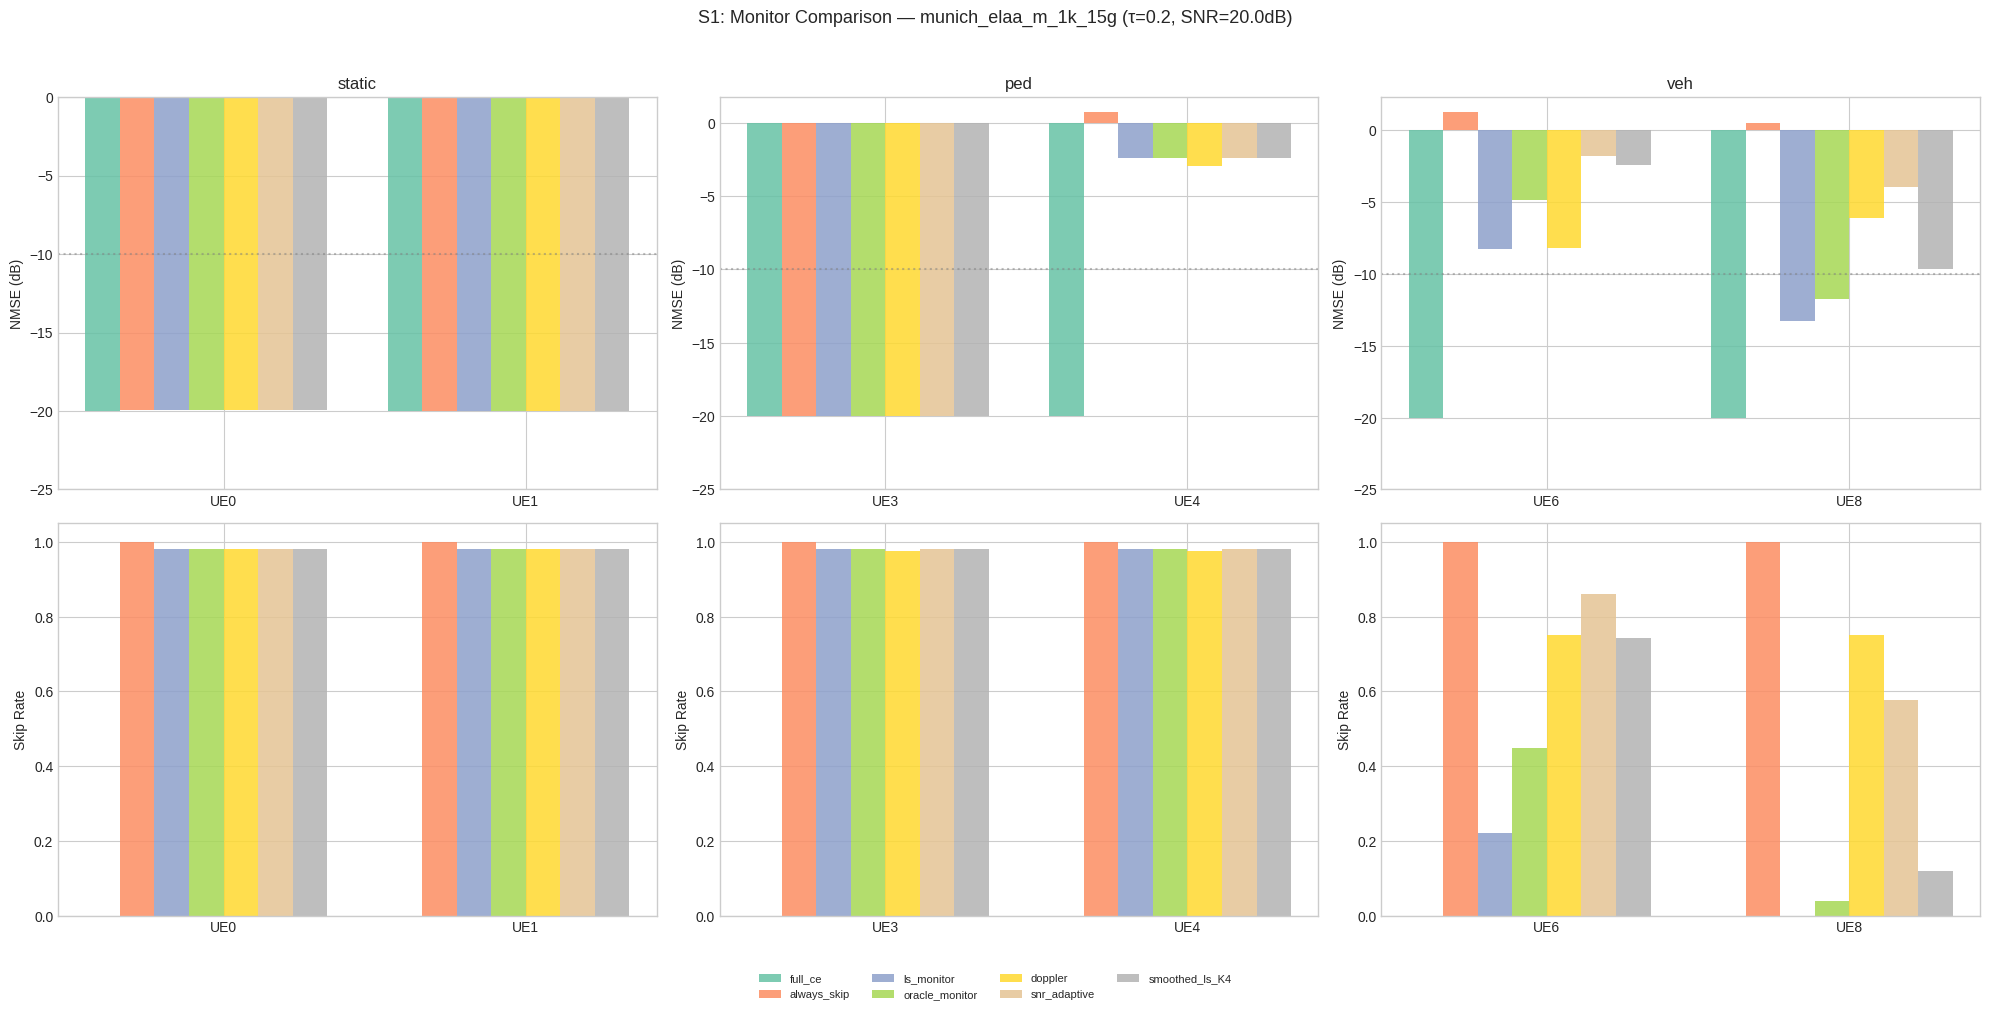


τ_base=0.2, τ_snr_adaptive=0.341

  static:
    Strategy             | UE 0 | UE 1
    --------------------------------------
    full_ce              | -20.0(0%) | -20.0(0%)
    always_skip          | -20.0(100%) | -20.0(100%)
    ls_monitor           | -20.0(98%) | -20.0(98%)
    oracle_monitor       | -20.0(98%) | -20.0(98%)
    doppler              | -20.0(98%) | -20.0(98%)
    snr_adaptive         | -20.0(98%) | -20.0(98%)
    smoothed_ls_K4       | -20.0(98%) | -20.0(98%)

  ped:
    Strategy             | UE 3 | UE 4
    --------------------------------------
    full_ce              | -20.0(0%) | -20.0(0%)
    always_skip          | -20.0(100%) |  +0.7(100%)
    ls_monitor           | -20.0(98%) |  -2.4(98%)
    oracle_monitor       | -20.0(98%) |  -2.4(98%)
    doppler              | -20.0(98%) |  -3.0(98%)
    snr_adaptive         | -20.0(98%) |  -2.4(98%)
    smoothed_ls_K4       | -20.0(98%) |  -2.4(98%)

  veh:
    Strategy             | UE 6 | UE 8
    ------------------

In [ ]:
from src.experiments.pipeline import run_s1
s1 = run_s1(ue_data, tau=0.2)

per_ue = s1["per_ue"]
strategy_names = list(per_ue[0]["strategies"].keys())
n_strat = len(strategy_names)
colors = plt.cm.Set2(np.linspace(0, 1, n_strat))

# Group UEs by speed
speed_groups = {"static": [], "ped": [], "veh": []}
for u in per_ue:
    lbl = "static" if u["speed"] < 0.1 else ("ped" if u["speed"] < 5 else "veh")
    speed_groups[lbl].append(u)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for col, (spd_label, ues) in enumerate(speed_groups.items()):
    if not ues:
        continue
    n_ue = len(ues)
    x = np.arange(n_ue)
    w = 0.8 / n_strat

    # Top row: NMSE
    ax = axes[0, col]
    for j, sname in enumerate(strategy_names):
        vals = [u["strategies"][sname]["nmse_db"] for u in ues]
        ax.bar(x + j * w, vals, w, label=sname if col == 0 else "", color=colors[j], alpha=0.85)
    ue_labels = [f"UE{u['uid']}" for u in ues]
    ax.set_xticks(x + w * n_strat / 2); ax.set_xticklabels(ue_labels)
    ax.set_ylabel("NMSE (dB)"); ax.set_title(f"{spd_label}")
    ax.axhline(-10, color="gray", ls=":", alpha=0.5)
    ax.set_ylim(bottom=min(-25, min(u["strategies"][s]["nmse_db"] for u in ues for s in strategy_names if u["strategies"][s]["nmse_db"] > -100) - 2))

    # Bottom row: Skip Rate
    ax = axes[1, col]
    for j, sname in enumerate(strategy_names):
        vals = [u["strategies"][sname]["skip_rate"] for u in ues]
        ax.bar(x + j * w, vals, w, label=sname if col == 0 else "", color=colors[j], alpha=0.85)
    ax.set_xticks(x + w * n_strat / 2); ax.set_xticklabels(ue_labels)
    ax.set_ylabel("Skip Rate"); ax.set_ylim(0, 1.05)

# Shared legend
handles, labels_lg = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_lg, loc="lower center", ncol=4, fontsize=8, bbox_to_anchor=(0.5, -0.02))

fig.suptitle(f"S1: Monitor Comparison — {ue_data['preset']} (τ={s1['tau']}, SNR={s1['snr_db']}dB)", fontsize=13)
plt.tight_layout(rect=[0, 0.04, 1, 0.96]); plt.show()

# Summary table
print(f"\nτ_base={s1['tau']}, τ_snr_adaptive={s1.get('tau_snr_adaptive','?'):.3f}")
for spd_label, ues in speed_groups.items():
    if not ues:
        continue
    print(f"\n  {spd_label}:")
    print(f"    {'Strategy':20s} | " + " | ".join(f"UE{u['uid']:>2d}" for u in ues))
    print(f"    {'-'*22}" + "--------" * len(ues))
    for sname in strategy_names:
        vals = [f"{u['strategies'][sname]['nmse_db']:+5.1f}" for u in ues]
        srs = [f"{u['strategies'][sname]['skip_rate']:.0%}" for u in ues]
        print(f"    {sname:20s} | " + " | ".join(f"{v}({s})" for v, s in zip(vals, srs)))

## S2: Threshold Sweep & Pareto Front — What is the optimal skip-quality tradeoff?

**Question:** As we vary the threshold tau from conservative (low, skip rarely) to aggressive (high, skip often), how does the NMSE-vs-skip-rate tradeoff curve look? Where is the sweet spot?

**Method:** Sweep tau across a range, running the best scheduling strategy from S1 at each value. Plot skip rate vs NMSE and computation ratio vs NMSE to identify the Pareto front.

**Key insight:** The sweet spot is the tau that achieves NMSE <= -10 dB with the lowest computation ratio (= fraction of slots requiring full CE). A steep Pareto curve means small tau changes drastically affect quality — the system is sensitive. A flat curve means there is a wide safe operating range.

S2: UEs:   0%|          | 0/6 [00:00<?, ?ue/s]

    τ sweep:   0%|          | 0/30 [00:00<?, ?τ/s]

  UE0: 30 τ values swept


    τ sweep:   0%|          | 0/30 [00:00<?, ?τ/s]

  UE1: 30 τ values swept


...

  UE4: 30 τ values swept


    τ sweep:   0%|          | 0/30 [00:00<?, ?τ/s]

  UE6: 30 τ values swept


    τ sweep:   0%|          | 0/30 [00:00<?, ?τ/s]

  UE8: 30 τ values swept


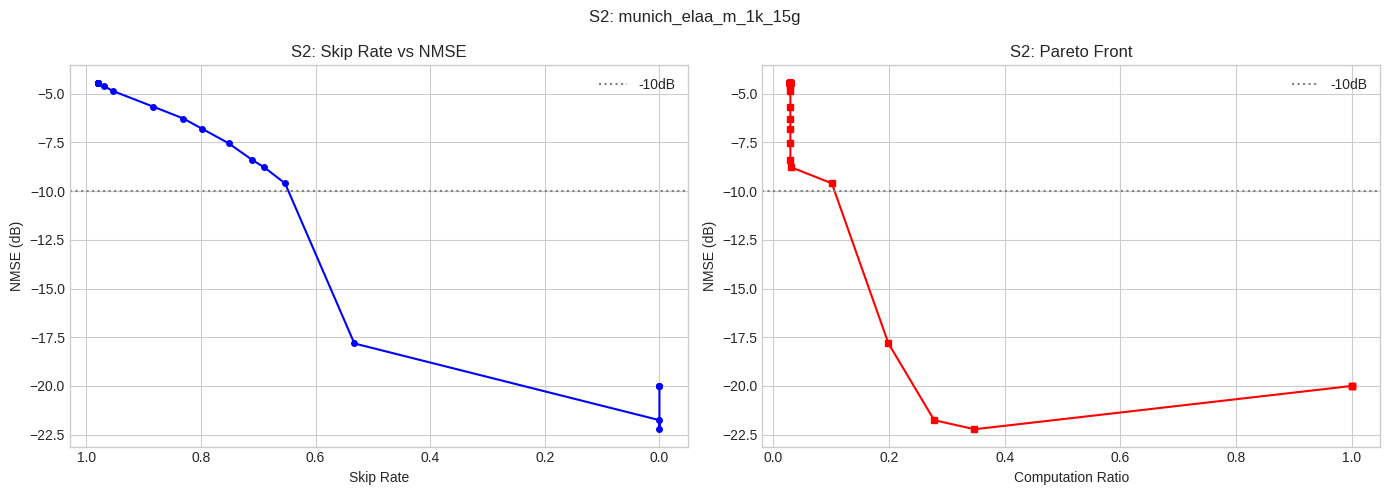

Sweet spot: τ=0.15, SR=53%, CR=0.199, NMSE=-17.8dB


In [ ]:
s2 = run_s2(ue_data)

sweep = s2["sweep"]
taus = [s["tau"] for s in sweep]
nmses_s2 = [s["avg_nmse_db"] for s in sweep]
srs = [s["skip_rate"] for s in sweep]
crs = [s["computation_ratio"] for s in sweep]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(srs, nmses_s2, "b-o", ms=4)
ax.set_xlabel("Skip Rate"); ax.set_ylabel("NMSE (dB)"); ax.set_title("S2: Skip Rate vs NMSE")
ax.axhline(-10, color="gray", ls=":", label="-10dB"); ax.legend(); ax.invert_xaxis()

ax = axes[1]
ax.plot(crs, nmses_s2, "r-s", ms=4)
ax.set_xlabel("Computation Ratio"); ax.set_ylabel("NMSE (dB)"); ax.set_title("S2: Pareto Front")
ax.axhline(-10, color="gray", ls=":", label="-10dB"); ax.legend()

fig.suptitle(f"S2: {PRESET}", fontsize=12); plt.tight_layout(); plt.show()

sweet = [s for s in sweep if s["avg_nmse_db"] <= -10]
if sweet:
    best = min(sweet, key=lambda s: s["computation_ratio"])
    print(f"Sweet spot: τ={best['tau']:.2f}, SR={best['skip_rate']:.0%}, CR={best['computation_ratio']:.3f}, NMSE={best['avg_nmse_db']:.1f}dB")

## S4: Delta Update Ablation — What to do during skipped slots?

**Question:** When CE is skipped, should we (a) purely reuse the old estimate, (b) apply EMA smoothing, or (c) apply an LS-delta correction? Which tier-1 update mode minimizes NMSE?

**Method:** Fix tau=0.2 and run the scheduler with each T1 update mode. Compare NMSE per speed class.

**Key insight:** Pure skip (no update) should work well for static UEs but degrade for mobile ones. EMA smoothing trades responsiveness for noise reduction. LS-delta correction attempts to track the channel drift but amplifies noise. The best mode likely depends on speed — look for whether one mode dominates across all classes or if a hybrid is needed.

S4: UEs:   0%|          | 0/6 [00:00<?, ?ue/s]

  S4 UE0 modes:   0%|          | 0/7 [00:00<?, ?m/s]

  S4 UE1 modes:   0%|          | 0/7 [00:00<?, ?m/s]

  S4 UE3 modes:   0%|          | 0/7 [00:00<?, ?m/s]

  S4 UE4 modes:   0%|          | 0/7 [00:00<?, ?m/s]

  S4 UE6 modes:   0%|          | 0/7 [00:00<?, ?m/s]

  S4 UE8 modes:   0%|          | 0/7 [00:00<?, ?m/s]

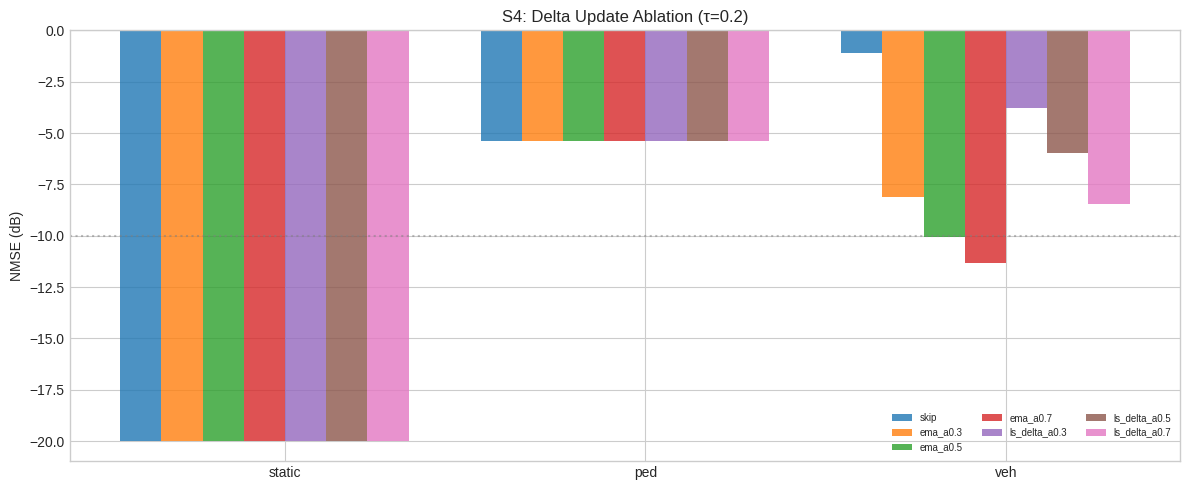

  static: best=skip → -20.0dB
  ped: best=skip → -5.4dB
  veh: best=ema_a0.7 → -11.3dB


In [ ]:
s4 = run_s4(ue_data)

modes = list(s4.keys())
speed_cats = ["static", "ped", "veh"]
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(speed_cats)); w = 0.8 / len(modes)
for j, mode in enumerate(modes):
    vals = [s4[mode].get(sc, {}).get("nmse_db", 0) for sc in speed_cats]
    ax.bar(x + j * w, vals, w, label=mode, alpha=0.8)
ax.set_xticks(x + w * len(modes) / 2); ax.set_xticklabels(speed_cats)
ax.set_ylabel("NMSE (dB)"); ax.set_title("S4: Delta Update Ablation (τ=0.2)")
ax.legend(fontsize=7, ncol=3); ax.axhline(-10, color="gray", ls=":", alpha=0.5)
plt.tight_layout(); plt.show()

for sc in speed_cats:
    best = min(modes, key=lambda m: s4[m].get(sc, {}).get("nmse_db", 0))
    print(f"  {sc}: best={best} → {s4[best].get(sc, {}).get('nmse_db', float('nan')):.1f}dB")

## S5: Beamforming Rate Impact — Does skipping CE hurt downstream performance?

**Question:** Channel estimation is not the end goal — beamforming rate is. When we skip CE and use a stale estimate for beamforming, how much achievable rate do we lose?

**Method:** Sweep SNR x tau combinations. For each, compute (1) Rate Preservation Ratio (RPR) = rate_with_skip / rate_with_perfect_CE, and (2) P(rate_loss > 5%) = fraction of slots exceeding 5% rate loss. Display as heatmaps.

**Key insight:** RPR > 0.95 with P(rate_loss > 5%) < 10% defines the "safe operating region." If the sweet spot covers a wide tau range at practical SNRs (10-20 dB), CE skip is viable for real deployment. A narrow safe region means the system is fragile to threshold mistuning.

S5: UEs:   0%|          | 0/6 [00:00<?, ?ue/s]

  S5 UE0 SNR:   0%|          | 0/4 [00:00<?, ?snr/s]

    τ sweep:   0%|          | 0/4 [00:00<?, ?τ/s]

    τ sweep:   0%|          | 0/4 [00:00<?, ?τ/s]

    τ sweep:   0%|          | 0/4 [00:00<?, ?τ/s]

...

  S5 UE8 SNR:   0%|          | 0/4 [00:00<?, ?snr/s]

    τ sweep:   0%|          | 0/4 [00:00<?, ?τ/s]

    τ sweep:   0%|          | 0/4 [00:00<?, ?τ/s]

    τ sweep:   0%|          | 0/4 [00:00<?, ?τ/s]

    τ sweep:   0%|          | 0/4 [00:00<?, ?τ/s]

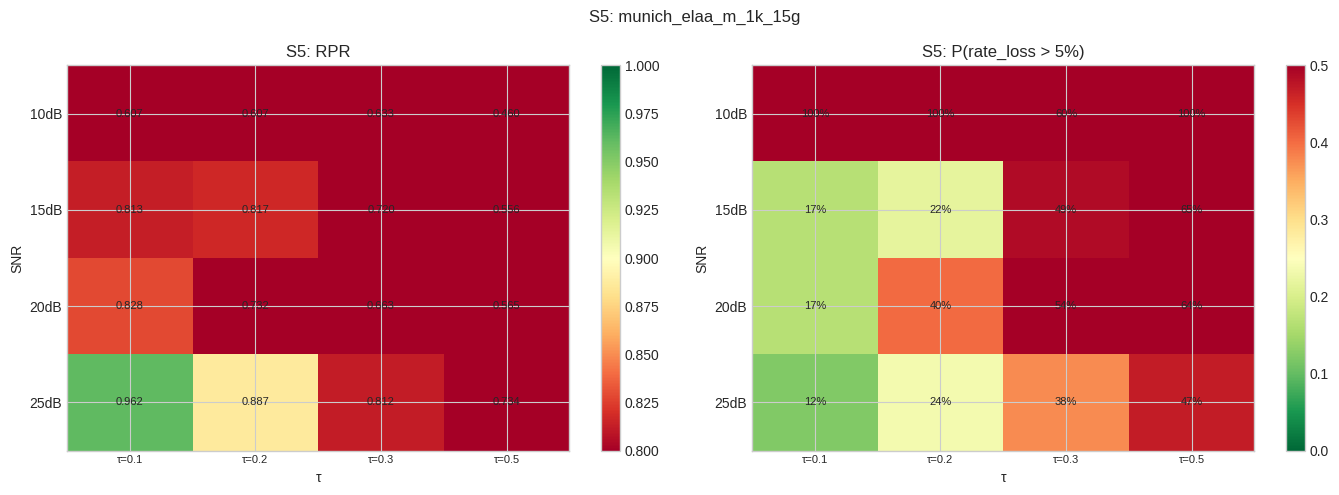

Sweet spots (RPR>0.95, P(rl>5%)<10%):


In [ ]:
s5 = run_s5(ue_data)

snr_keys = sorted(s5.keys()); tau_keys = sorted(s5[snr_keys[0]].keys())
rpr_mat = np.array([[s5[sk][tk]["avg_rpr"] for tk in tau_keys] for sk in snr_keys])
rl5_mat = np.array([[s5[sk][tk]["frac_above_5pct"] for tk in tau_keys] for sk in snr_keys])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mat, cmap, vr, title in [
    (axes[0], rpr_mat, "RdYlGn", (0.8, 1.0), "RPR"),
    (axes[1], rl5_mat, "RdYlGn_r", (0, 0.5), "P(rate_loss > 5%)"),
]:
    im = ax.imshow(mat, aspect="auto", cmap=cmap, vmin=vr[0], vmax=vr[1])
    ax.set_xticks(range(len(tau_keys))); ax.set_xticklabels([t.replace("tau","τ=") for t in tau_keys], fontsize=8)
    ax.set_yticks(range(len(snr_keys))); ax.set_yticklabels([s.replace("snr","")+"dB" for s in snr_keys])
    ax.set_xlabel("τ"); ax.set_ylabel("SNR"); ax.set_title(f"S5: {title}")
    for i in range(len(snr_keys)):
        for j in range(len(tau_keys)):
            fmt = f"{mat[i,j]:.3f}" if "RPR" in title else f"{mat[i,j]:.0%}"
            ax.text(j, i, fmt, ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax)
fig.suptitle(f"S5: {PRESET}", fontsize=12); plt.tight_layout(); plt.show()

print("Sweet spots (RPR>0.95, P(rl>5%)<10%):")
for i, sk in enumerate(snr_keys):
    for j, tk in enumerate(tau_keys):
        if rpr_mat[i,j] > 0.95 and rl5_mat[i,j] < 0.10:
            print(f"  ✓ {sk} {tk}: RPR={rpr_mat[i,j]:.3f}")

## S3: Distance-Dependent Threshold — Should near-field and far-field UEs use different tau?

**Question:** Does the UE's distance from the BS (and specifically its position relative to the Rayleigh distance) affect channel variability, and should the skip threshold be adapted accordingly?

**Method:** Classify UEs into near-field (d < R_Rayleigh), transition (R < d < 3R), and far-field (d > 3R) zones. Plot median oracle delta vs distance and compute the optimal tau per zone.

**Key insight:** Near-field channels may exhibit different fading characteristics (spherical wavefront, spatial non-stationarity). If optimal tau differs significantly across zones, a distance-aware scheduler can outperform a single global threshold. If tau is similar across zones, distance adaptation is unnecessary overhead.

S3: UEs:   0%|          | 0/6 [00:00<?, ?ue/s]

    τ sweep:   0%|          | 0/30 [00:00<?, ?τ/s]

  UE0 (FF, nanm): 30 τ swept


    τ sweep:   0%|          | 0/30 [00:00<?, ?τ/s]

  UE1 (FF, nanm): 30 τ swept


...

  UE4 (FF, nanm): 30 τ swept


    τ sweep:   0%|          | 0/30 [00:00<?, ?τ/s]

  UE6 (FF, nanm): 30 τ swept


    τ sweep:   0%|          | 0/30 [00:00<?, ?τ/s]

  UE8 (FF, nanm): 30 τ swept


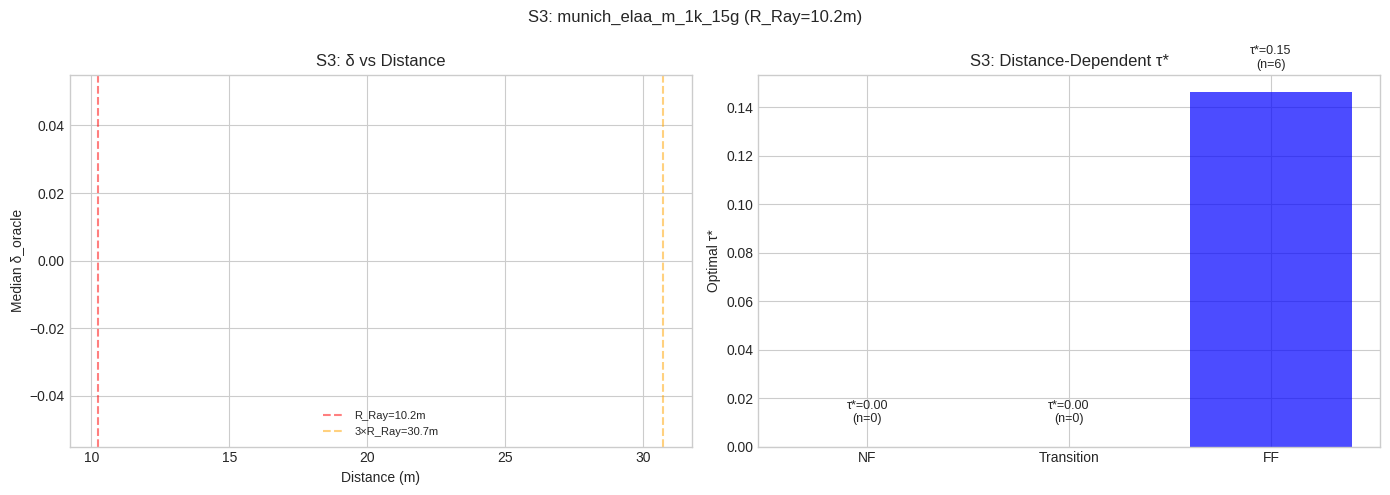

In [ ]:
s3 = run_s3(ue_data)
r_ray = s3["r_rayleigh"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for u in s3["per_ue"]:
    c = {"NF": "red", "Transition": "orange", "FF": "blue"}.get(u["zone"], "gray")
    s0_match = [x for x in s0["per_ue"] if x["uid"] == u["uid"]]
    d = s0_match[0]["median_delta"] if s0_match else 0
    ax.scatter(u["dist"], d, c=c, s=80, edgecolors="k", linewidths=0.5, zorder=5)
    ax.annotate(f"UE{u['uid']}", (u["dist"], d), textcoords="offset points", xytext=(5, 3), fontsize=7)
ax.axvline(r_ray, color="red", ls="--", alpha=0.5, label=f"R_Ray={r_ray:.1f}m")
ax.axvline(3 * r_ray, color="orange", ls="--", alpha=0.5, label=f"3×R_Ray={3*r_ray:.1f}m")
ax.set_xlabel("Distance (m)"); ax.set_ylabel("Median δ_oracle"); ax.set_title("S3: δ vs Distance"); ax.legend(fontsize=8)

ax = axes[1]
zones = ["NF", "Transition", "FF"]
taus_z = [s3["zones"].get(z, {}).get("optimal_tau", 0) or 0 for z in zones]
counts = [s3["zones"].get(z, {}).get("count", 0) for z in zones]
ax.bar(range(3), taus_z, color=["red", "orange", "blue"], alpha=0.7)
for i, (t, c) in enumerate(zip(taus_z, counts)):
    ax.text(i, t + 0.01, f"τ*={t:.2f}\n(n={c})", ha="center", fontsize=9)
ax.set_xticks(range(3)); ax.set_xticklabels(zones); ax.set_ylabel("Optimal τ*"); ax.set_title("S3: Distance-Dependent τ*")

fig.suptitle(f"S3: {PRESET} (R_Ray={r_ray:.1f}m)", fontsize=12); plt.tight_layout(); plt.show()

## S7: System Overhead & Effective Throughput — Is the overhead worth the savings?

**Question:** The CE skip scheduler itself has computational cost (LS estimation for monitoring, delta calculation). Does the pilot overhead saved by skipping CE outweigh the scheduler's own cost?

**Method:** Break down per-slot timing: LS estimation, delta monitoring, and full CE (LMMSE). Using S2's sweet-spot skip rate, compute effective throughput gain = pilot slots saved / (monitor overhead + remaining CE cost). Also estimate system capacity multiplier (more UEs servable with freed pilot resources).

**Key insight:** The overhead ratio should be negligible (< 0.1%). The capacity multiplier and throughput gain are the paper's headline numbers — they quantify the practical value of CE skip. A system throughput gain > 1.5x with NMSE < -10 dB is a strong result.

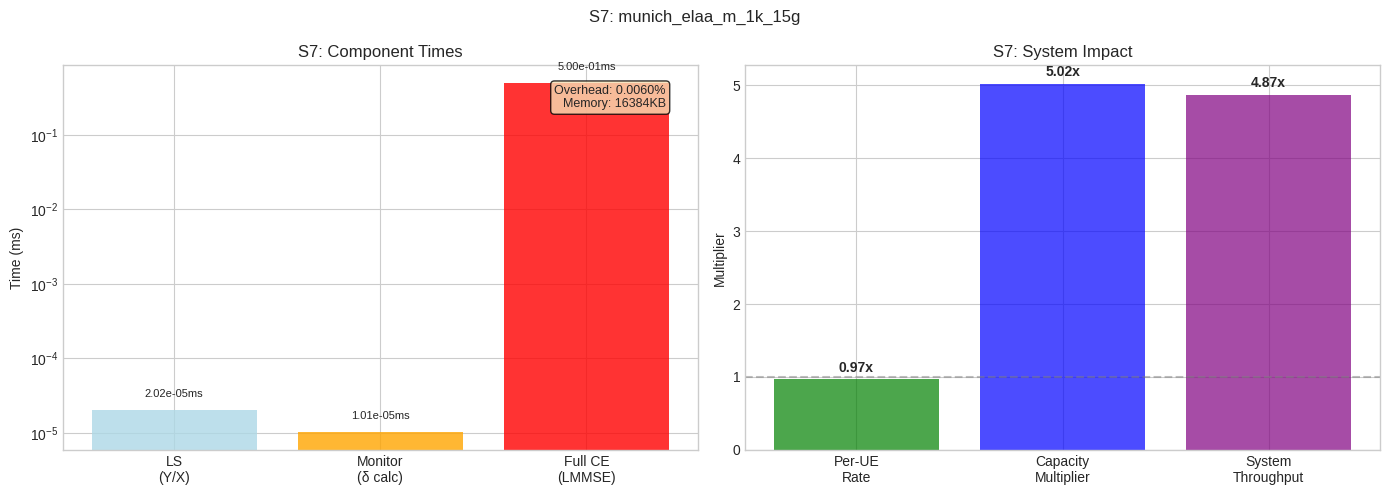

Overhead: 0.0060% | Capacity: 5.0x | Throughput: 4.9x


In [ ]:
s7 = run_s7(ue_data, s2_result=s2)

oh = s7["overhead"]; eff = s7["effective_throughput"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars = ax.bar(["LS\n(Y/X)", "Monitor\n(δ calc)", "Full CE\n(LMMSE)"],
              [oh["t_ls_ms"], oh["t_monitor_ms"], oh["t_full_ce_ms"]],
              color=["lightblue", "orange", "red"], alpha=0.8)
ax.set_ylabel("Time (ms)"); ax.set_yscale("log"); ax.set_title("S7: Component Times")
for b, t in zip(bars, [oh["t_ls_ms"], oh["t_monitor_ms"], oh["t_full_ce_ms"]]):
    ax.text(b.get_x() + b.get_width()/2, t * 1.5, f"{t:.2e}ms", ha="center", fontsize=8)
ax.text(0.95, 0.95, f"Overhead: {oh['overhead_ratio']:.4%}\nMemory: {oh['memory_bytes']/1024:.0f}KB",
        transform=ax.transAxes, va="top", ha="right", fontsize=9, bbox=dict(boxstyle="round", fc="wheat", alpha=0.8))

ax = axes[1]
vals = [eff["per_ue_rate_factor"], eff["capacity_multiplier"], eff["system_throughput_gain"]]
bars = ax.bar(["Per-UE\nRate", "Capacity\nMultiplier", "System\nThroughput"], vals, color=["green","blue","purple"], alpha=0.7)
ax.axhline(1.0, color="gray", ls="--", alpha=0.5)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.1, f"{v:.2f}x", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Multiplier"); ax.set_title("S7: System Impact")

fig.suptitle(f"S7: {PRESET}", fontsize=12); plt.tight_layout(); plt.show()
print(f"Overhead: {oh['overhead_ratio']:.4%} | Capacity: {eff['capacity_multiplier']:.1f}x | Throughput: {eff['system_throughput_gain']:.1f}x")